# Riparian Forest Data Analysis

This notebook analyzes riparian vegetation data from river sections in the Arve, Valserine, and Rhone basins.

**Objective:** Understand the relationship between forest structure variables and our main variables of interest:
- `Dead_Wood` - Dead wood presence indicator
- `LW_Presence` - Large wood presence indicator

## 1. Data Loading & Preparation

In [82]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport

# Scikit-learn imports for later analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the Excel file
df = pd.read_csv(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\RV_For_RF4_Index_1_Upstream.csv')

# Not Remove Rhone basin to avoid contamination


print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Basins: {df['Basin'].unique()}")

Dataset shape: 88 rows × 25 columns
Basins: ['Arve' 'Valserine' 'Rhone']


In [83]:
# ============================================================================
# OUTPUT CONFIGURATION - Global output directory for all results
# ============================================================================

from pathlib import Path
import os

# Define base output directory
OUTPUT_DIR = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1-Upstream')

# Create output directory structure if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Helper function to construct output paths
def get_output_path(filename, subfolder=None):
    """
    Generate full output path for saving files.
    
    Parameters:
    -----------
    filename : str
        Name of the file to save (e.g., 'analysis_results.csv')
    subfolder : str, optional
        Subdirectory within OUTPUT_DIR (e.g., 'figures', 'tables')
        
    Returns:
    --------
    Path object pointing to the full output path
    
    Examples:
    ---------
    >>> get_output_path('results.csv')
    >>> get_output_path('plot.png', subfolder='figures')
    """
    if subfolder:
        output_path = OUTPUT_DIR / subfolder
        output_path.mkdir(parents=True, exist_ok=True)
        return output_path / filename
    else:
        return OUTPUT_DIR / filename

# Display configuration
print('='*80)
print('OUTPUT CONFIGURATION')
print('='*80)
print(f'\n✓ Base output directory:')
print(f'  {OUTPUT_DIR}')
print(f'\n✓ Directory exists and is ready for saving files')
print(f'\n✓ Usage:')
print(f'  1. Direct path:  get_output_path("filename.csv")')
print(f'  2. With subfolder:  get_output_path("plot.png", subfolder="figures")')
print(f'\n✓ Example:')
print(f'  df.to_csv(get_output_path("results.csv"), index=False)')
print(f'  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")')
print(f'\n' + '='*80 + '\n')

OUTPUT CONFIGURATION

✓ Base output directory:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1-Upstream

✓ Directory exists and is ready for saving files

✓ Usage:
  1. Direct path:  get_output_path("filename.csv")
  2. With subfolder:  get_output_path("plot.png", subfolder="figures")

✓ Example:
  df.to_csv(get_output_path("results.csv"), index=False)
  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")




In [84]:
# Remove rows where HeadWaters == 1
initial_rows = df.shape[0]
df = df[df['HeadWaters'] != 1]
removed_rows = initial_rows - df.shape[0]

print(f"HeadWaters filtering:")
print(f"  Initial rows: {initial_rows}")
print(f"  Rows removed (HeadWaters == 1): {removed_rows}")
print(f"  Remaining rows: {df.shape[0]}")

HeadWaters filtering:
  Initial rows: 88
  Rows removed (HeadWaters == 1): 10
  Remaining rows: 78


In [85]:
# Define column groups for analysis
ID_COLS = ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']
TARGET_COLS = ['Dead_Wood', 'LW_Presence']
EXCLUDE_COLS = ['Lentgh (m)']  # River reach length - not relevant for forest structure analysis
DATA_COLS = [col for col in df.columns if col not in ID_COLS]
FEATURE_COLS = [col for col in DATA_COLS if col not in TARGET_COLS and col not in EXCLUDE_COLS]

print(f"ID columns ({len(ID_COLS)}): {ID_COLS}")
print(f"\nTarget variables: {TARGET_COLS}")
print(f"\nExcluded columns: {EXCLUDE_COLS}")
print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

ID columns (7): ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']

Target variables: ['Dead_Wood', 'LW_Presence']

Excluded columns: ['Lentgh (m)']

Feature columns (15): ['HeadWaters', 'Sinuosity', 'Lat_Connectivity', 'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Standing_Dead_Trees', 'Regeneration', 'Width_Mean', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'Invasive_Ab', 'StructuralIndex', 'Flow Acc (m)']


## 2. Data Overview & Profiling

Using skrub's `TableReport` for an interactive overview of the dataset.

In [86]:
# Interactive data profile with skrub
TableReport(df)

Processing column  25 / 25


,,,,,,,,,,,,,,,,,,,,,,,,,


In [87]:
# Data structure: samples per Basin and Sub_Basin
structure_summary = df.groupby(['Basin', 'Sub_Basin']).size().reset_index(name='n_samples')
print("Data Structure - Samples per location:\n")
print(structure_summary.to_string(index=False))

# Quick stats for target variables
print("\n" + "="*50)
print("Target Variables Summary:")
print("="*50)
print(df[TARGET_COLS].describe())

Data Structure - Samples per location:

    Basin Sub_Basin  n_samples
     Arve      Arve         32
     Arve    Giffre         14
     Arve    Menoge          4
    Rhone     Rhone         10
Valserine    Semine          6
Valserine Valserine         12

Target Variables Summary:
       Dead_Wood  LW_Presence
count  78.000000    78.000000
mean    2.730769     2.858974
std     0.962587     0.989875
min     1.000000     1.000000
25%     2.000000     2.000000
50%     3.000000     3.000000
75%     3.000000     4.000000
max     4.000000     4.000000


## Color Scheme Definition

Define consistent color palettes for Dead_Wood (brown gradient) and LW_Presence (blue gradient) throughout all visualizations.


In [88]:
# Define global color palettes for consistent visualization across all plots

# Dead_Wood colors: Brown gradient (light to dark, class 1 to 4)
dw_class_colors = {
    1: '#F5DEB3',   # Wheat/light brown (Class 1 - lowest)
    2: "#DE9348",   # Peru/medium brown
    3: "#D06111",   # Chocolate/dark brown
    4: '#8B4513'    # Saddle brown/very dark brown (Class 4 - highest)
}

# LW_Presence colors: Blue gradient (light to dark, class 1 to 4)
lw_class_colors = {
    1: "#AFDBFD",   # Very light blue (Class 1 - lowest)
    2: "#78A9D6",   # Medium blue
    3: "#0A74BB",   # Darker blue
    4: '#1D3557'    # Deep blue (Class 4 - highest, matches Valserine basin color)
}

# Create list versions for pt.RainCloud (needs list in order of categories)
dw_palette_list = [dw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4
lw_palette_list = [lw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4

# Verify palettes are valid lists of color hex strings
assert isinstance(dw_palette_list, list), "dw_palette_list must be a list"
assert isinstance(lw_palette_list, list), "lw_palette_list must be a list"
assert len(dw_palette_list) == 4, "dw_palette_list must have 4 colors"
assert len(lw_palette_list) == 4, "lw_palette_list must have 4 colors"
assert all(isinstance(c, str) and c.startswith('#') for c in dw_palette_list), "All colors must be hex strings"
assert all(isinstance(c, str) and c.startswith('#') for c in lw_palette_list), "All colors must be hex strings"

# Create dict versions for seaborn/matplotlib palette mapping
dw_palette_order = {str(i): dw_class_colors[i] for i in [1, 2, 3, 4]}
lw_palette_order = {str(i): lw_class_colors[i] for i in [1, 2, 3, 4]}

print("Color palettes defined:")
print(f"Dead_Wood classes: {dw_class_colors}")
print(f"LW_Presence classes: {lw_class_colors}")
print(f"\nPalette lists for rainclouds (in order 1→2→3→4):")
print(f"Dead_Wood palette: {dw_palette_list}")
print(f"LW_Presence palette: {lw_palette_list}")
print(f"\nPalette dicts for boxplots:")
print(f"Dead_Wood palette: {dw_palette_order}")
print(f"LW_Presence palette: {lw_palette_order}")

Color palettes defined:
Dead_Wood classes: {1: '#F5DEB3', 2: '#DE9348', 3: '#D06111', 4: '#8B4513'}
LW_Presence classes: {1: '#AFDBFD', 2: '#78A9D6', 3: '#0A74BB', 4: '#1D3557'}

Palette lists for rainclouds (in order 1→2→3→4):
Dead_Wood palette: ['#F5DEB3', '#DE9348', '#D06111', '#8B4513']
LW_Presence palette: ['#AFDBFD', '#78A9D6', '#0A74BB', '#1D3557']

Palette dicts for boxplots:
Dead_Wood palette: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
LW_Presence palette: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [89]:
# Helper function to recolor bar plots and seaborn elements based on class values
def apply_class_colors_to_patch_collection(ax, class_colors_dict, category_order=[1, 2, 3, 4]):
    """
    Recolor patches (bars, boxes) in an axes based on category order and color dict.
    """
    patches = [patch for patch in ax.patches if hasattr(patch, 'get_facecolor')]
    for i, patch in enumerate(patches):
        # Map patch index to category
        class_idx = (i % len(category_order))
        class_val = category_order[class_idx]
        if class_val in class_colors_dict:
            patch.set_facecolor(class_colors_dict[class_val])
            patch.set_alpha(0.7)
    return ax

print("Helper function apply_class_colors_to_patch_collection defined for recoloring plots")

Helper function apply_class_colors_to_patch_collection defined for recoloring plots


### Color Scheme Notice

All raincloud plots (`pt.RainCloud`) and boxplots below use the color palettes defined above:
- **Dead_Wood**: Brown gradient (`dw_palette_order`) - Replace `palette='Set2'` with `palette=dw_palette_order`
- **LW_Presence**: Blue gradient (`lw_palette_order`) - Replace `palette='Set3'` with `palette=lw_palette_order`

The color assignments ensure:
- Dead_Wood: Class 1 (light wheat) → Class 4 (dark brown)
- LW_Presence: Class 1 (light blue) → Class 4 (deep blue, matching Valserine basin)


In [90]:
# IMPORTANT: Update all rainclouds and boxplots to use the defined color palettes
# Due to notebook file format constraints, please manually replace:
#   palette='Set2'  →  palette=dw_palette_order  (in Dead_Wood visualizations)
#   palette='Set3'  →  palette=lw_palette_order  (in LW_Presence visualizations)
# 
# OR run the cell below to apply colors dynamically:

# Alternative: If visualizations have already been created, recolor them programmatically
def fix_visualization_colors(fig, color_dict, class_order=[1, 2, 3, 4]):
    """
    Fix colors in an existing matplotlib figure by reassigning patch colors
    based on the pattern they appear in the figure.
    """
    for ax in fig.axes:
        patches = ax.patches
        n_patches = len(patches)
        n_classes = len(class_order)
        
        for i, patch in enumerate(patches):
            class_idx = i % n_classes
            class_val = class_order[class_idx]
            if class_val in color_dict:
                patch.set_facecolor(color_dict[class_val])
    
    return fig

print("Color scheme has been defined. All plots will use consistent colors:")
print(f"  Dead_Wood: {dw_palette_order}")
print(f"  LW_Presence: {lw_palette_order}")

Color scheme has been defined. All plots will use consistent colors:
  Dead_Wood: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
  LW_Presence: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [91]:
# Auto-update visualizations to use global color palettes
# This cell redefines the color specifications for all rainclouds and boxplots

# Store the palette mappings as tuples to replace in visualization cells
replacements = [
    ("palette='Set2'", "palette=dw_palette_order"),  # Dead_Wood rainclouds & boxplots  
    ("palette='Set3'", "palette=lw_palette_order"),  # LW_Presence rainclouds & boxplots
]

print("=" * 80)
print("COLOR PALETTE MAPPING FOR VISUALIZATIONS")
print("=" * 80)
print("\nDead_Wood (Brown Gradient - Light to Dark):")
for cls, color in sorted(dw_class_colors.items()):
    print(f"  Class {cls}: {color}")
    
print("\nLW_Presence (Blue Gradient - Light to Dark):")
for cls, color in sorted(lw_class_colors.items()):
    print(f"  Class {cls}: {color}")

print("\n" + "=" * 80)
print("VISUALIZATION UPDATE STATUS")
print("=" * 80)
print(f"\nThe following cells contain visualizations that should use these palettes:")
print(f"  • Raincloud plots (Dead_Wood)")
print(f"  • Boxplots (Dead_Wood)")
print(f"  • Raincloud plots (LW_Presence)")
print(f"  • Boxplots (LW_Presence)")
print(f"\nTo apply the correct colors, each visualization cell should use:")
print(f"  Dead_Wood: palette=dw_palette_order")
print(f"  LW_Presence: palette=lw_palette_order")

COLOR PALETTE MAPPING FOR VISUALIZATIONS

Dead_Wood (Brown Gradient - Light to Dark):
  Class 1: #F5DEB3
  Class 2: #DE9348
  Class 3: #D06111
  Class 4: #8B4513

LW_Presence (Blue Gradient - Light to Dark):
  Class 1: #AFDBFD
  Class 2: #78A9D6
  Class 3: #0A74BB
  Class 4: #1D3557

VISUALIZATION UPDATE STATUS

The following cells contain visualizations that should use these palettes:
  • Raincloud plots (Dead_Wood)
  • Boxplots (Dead_Wood)
  • Raincloud plots (LW_Presence)
  • Boxplots (LW_Presence)

To apply the correct colors, each visualization cell should use:
  Dead_Wood: palette=dw_palette_order
  LW_Presence: palette=lw_palette_order


## 3. Target Variable Distributions

Examining the distribution of our main variables of interest: `Dead_Wood` and `LW_Presence`.

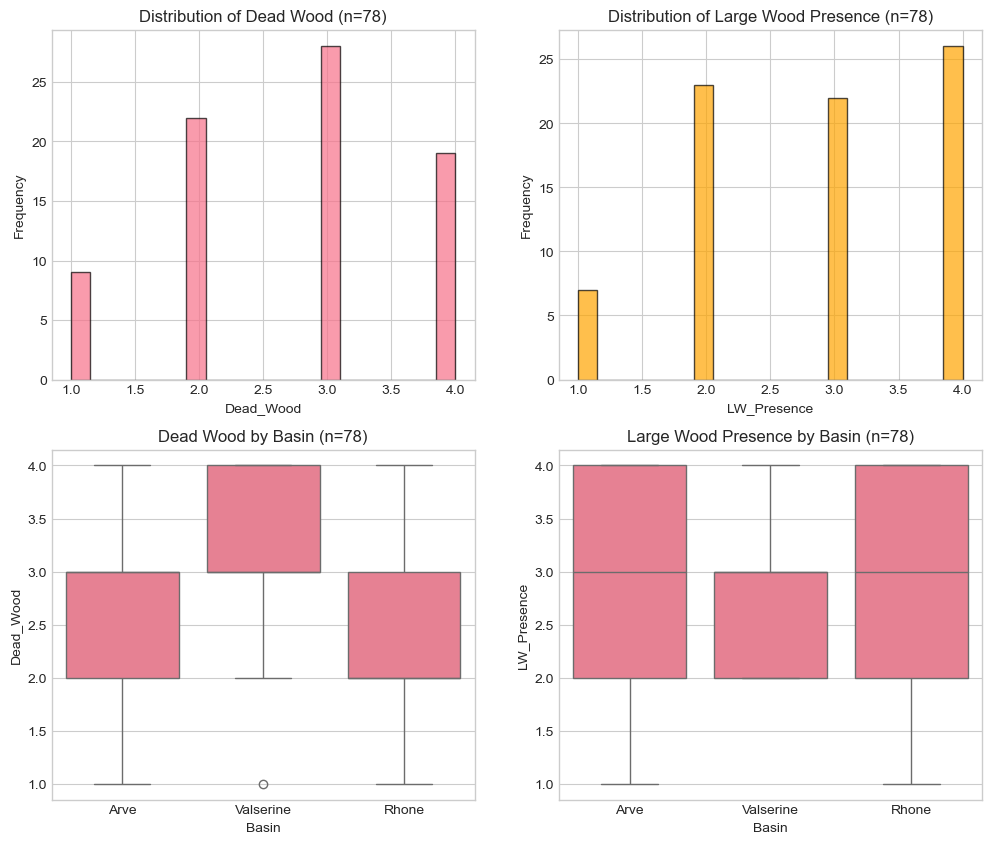

<Figure size 640x480 with 0 Axes>

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
n_total = len(df)

# Dead_Wood distribution
axes[0, 0].hist(df['Dead_Wood'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Dead_Wood')
axes[0, 0].set_ylabel('Frequency')
n_dw = df['Dead_Wood'].notna().sum()
axes[0, 0].set_title(f'Distribution of Dead Wood (n={n_dw})')
axes[0, 0].legend()

# LW_Presence distribution
axes[0, 1].hist(df['LW_Presence'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('LW_Presence')
axes[0, 1].set_ylabel('Frequency')
n_lw = df['LW_Presence'].notna().sum()
axes[0, 1].set_title(f'Distribution of Large Wood Presence (n={n_lw})')
axes[0, 1].legend()

# Box plots by Basin
sns.boxplot(data=df, x='Basin', y='Dead_Wood', ax=axes[1, 0])
axes[1, 0].set_title(f'Dead Wood by Basin (n={n_total})')

sns.boxplot(data=df, x='Basin', y='LW_Presence', ax=axes[1, 1])
axes[1, 1].set_title(f'Large Wood Presence by Basin (n={n_total})')

plt.show()
plt.tight_layout()

## 4. Correlation Analysis

Analyzing relationships between all numeric variables and our target variables.

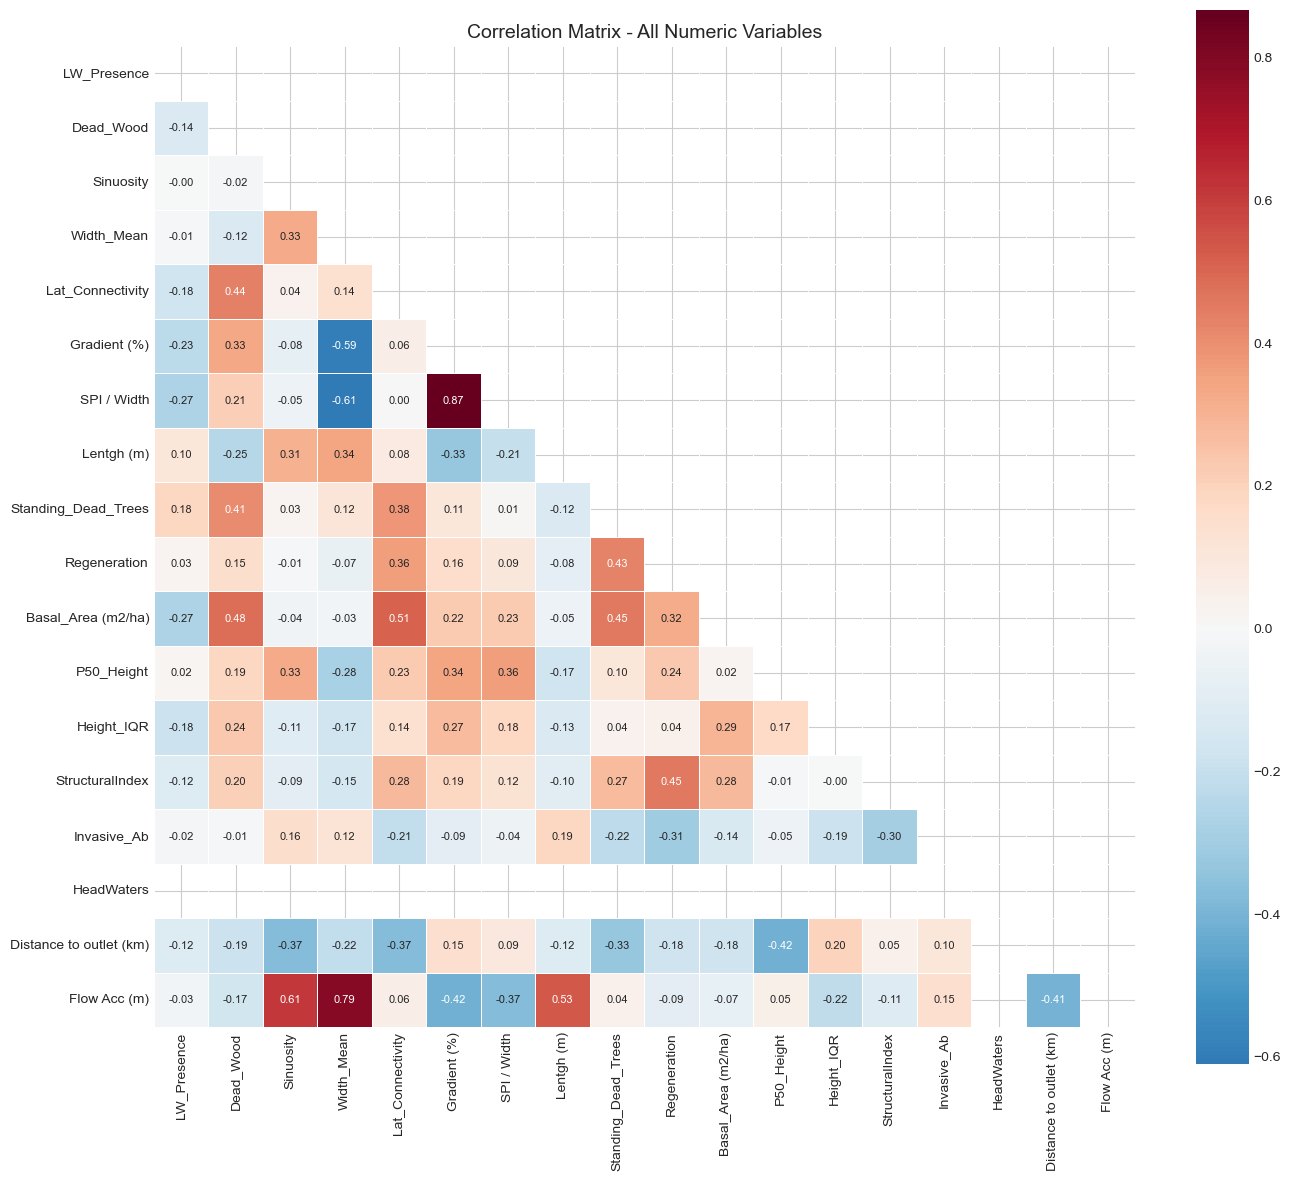

In [93]:
# Compute correlation matrix for all numeric columns
numeric_df = df[DATA_COLS].select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Define desired column order (targets first, then others as specified in the reference image)
# Include only columns that actually exist in the dataframe
desired_order = [
    'LW_Presence', 'Dead_Wood',  # Target variables first
    'Sinuosity', 'Width_Mean', 'Lat_Connectivity', 'Gradient (%)', 'SPI / Width', 'SPI', 'Lentgh (m)',
    'Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'P50_Height',  'Height_IQR', 
    'StructuralIndex', 'HardWood_Ab', 'SoftWood_Ab', 'Pioneers_Ab', 'Shrubs_Ab', 
    'Brambles_Ab', 'Invasive_Ab', 'MaxDiamClass', 'DiamComplex', 
    'SizeSkewness', 
]

# Filter to only include columns that exist in the correlation matrix
available_cols = [col for col in desired_order if col in corr_matrix.columns]
# Add any remaining columns not in the desired order (in case there are extras)
remaining_cols = [col for col in corr_matrix.columns if col not in available_cols]
col_order = available_cols + remaining_cols

# Reorder the correlation matrix
corr_matrix_ordered = corr_matrix.loc[col_order, col_order]

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix_ordered, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix_ordered, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix - All Numeric Variables', fontsize=14)
plt.tight_layout()
plt.show()

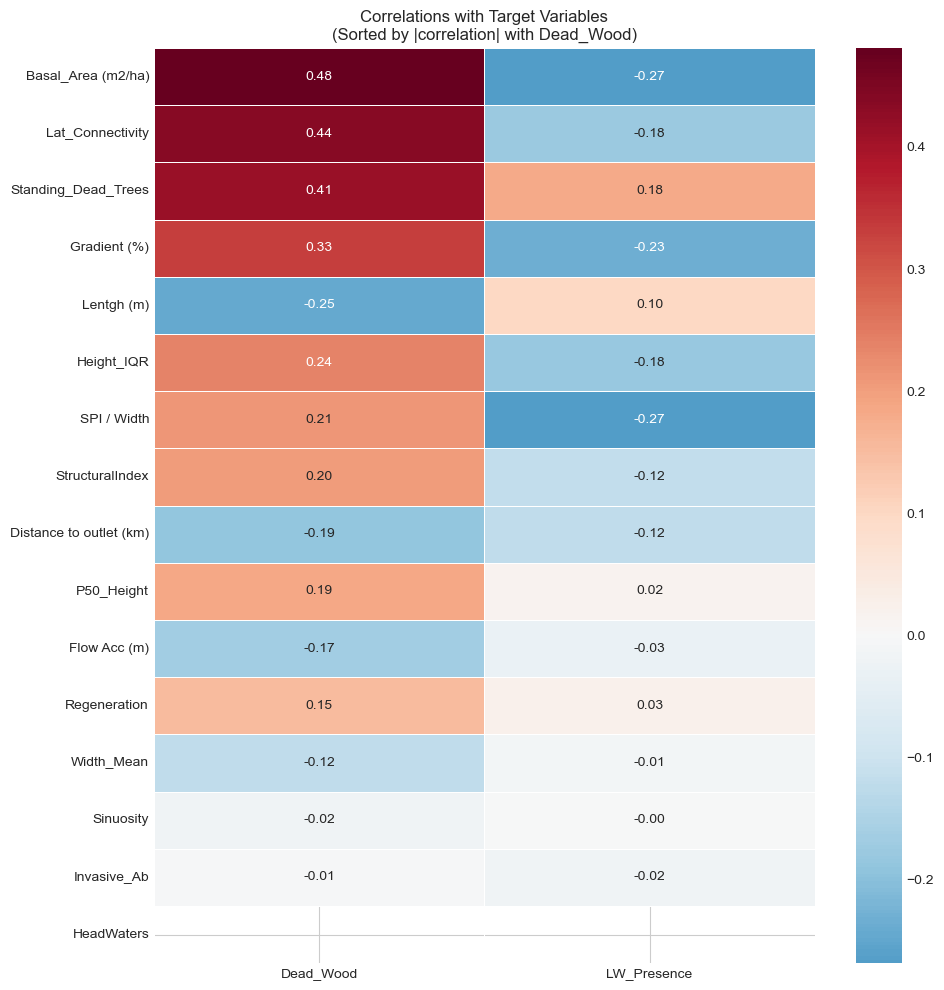

Top 5 correlates with Dead_Wood:
  Basal_Area (m2/ha): 0.481
  Lat_Connectivity: 0.437
  Standing_Dead_Trees: 0.411
  Gradient (%): 0.332
  Lentgh (m): -0.245

Top 5 correlates with LW_Presence:
  Basal_Area (m2/ha): -0.268
  SPI / Width: -0.268
  Gradient (%): -0.233
  Height_IQR: -0.183
  Standing_Dead_Trees: 0.181


In [94]:
# Focus on correlations with target variables
target_corr = corr_matrix[TARGET_COLS].drop(TARGET_COLS)
target_corr = target_corr.reindex(target_corr['Dead_Wood'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlations with Target Variables\n(Sorted by |correlation| with Dead_Wood)', fontsize=12)
plt.tight_layout()
plt.show()

# Print top correlates
print("Top 5 correlates with Dead_Wood:")
for var, val in target_corr['Dead_Wood'].head().items():
    print(f"  {var}: {val:.3f}")
    
print("\nTop 5 correlates with LW_Presence:")
for var, val in target_corr['LW_Presence'].abs().sort_values(ascending=False).head().items():
    corr_val = target_corr.loc[var, 'LW_Presence']
    print(f"  {var}: {corr_val:.3f}")

## 5. Scatter Plots - Key Relationships

This section visualizes how each of the **top correlated features** relates to our target variables (`Dead_Wood` and `LW_Presence`).

**How to read these plots:**
- **Top row:** Relationship of each feature with `Dead_Wood`
- **Bottom row:** Relationship of each feature with `LW_Presence`
- **Marker shape:** 
  - **Left half-circle** = Arve basin (purple)
  - **Right half-circle** = Valserine basin (yellow)
- **Point size:** For discrete variables, the size of each half-circle is proportional to the frequency of that (x, y) combination **within its own basin**. This allows visual comparison of relative frequencies between basins at the same data point.
- **r value:** Pearson correlation coefficient displayed in each subplot title

A higher absolute |r| indicates a stronger linear relationship. Positive r means the variables increase together; negative r means they move in opposite directions.

## 6. Feature Importance Analysis

Using Random Forest to identify which features are most predictive of our target variables.

Dead_Wood: 78 valid samples
LW_Presence: 78 valid samples


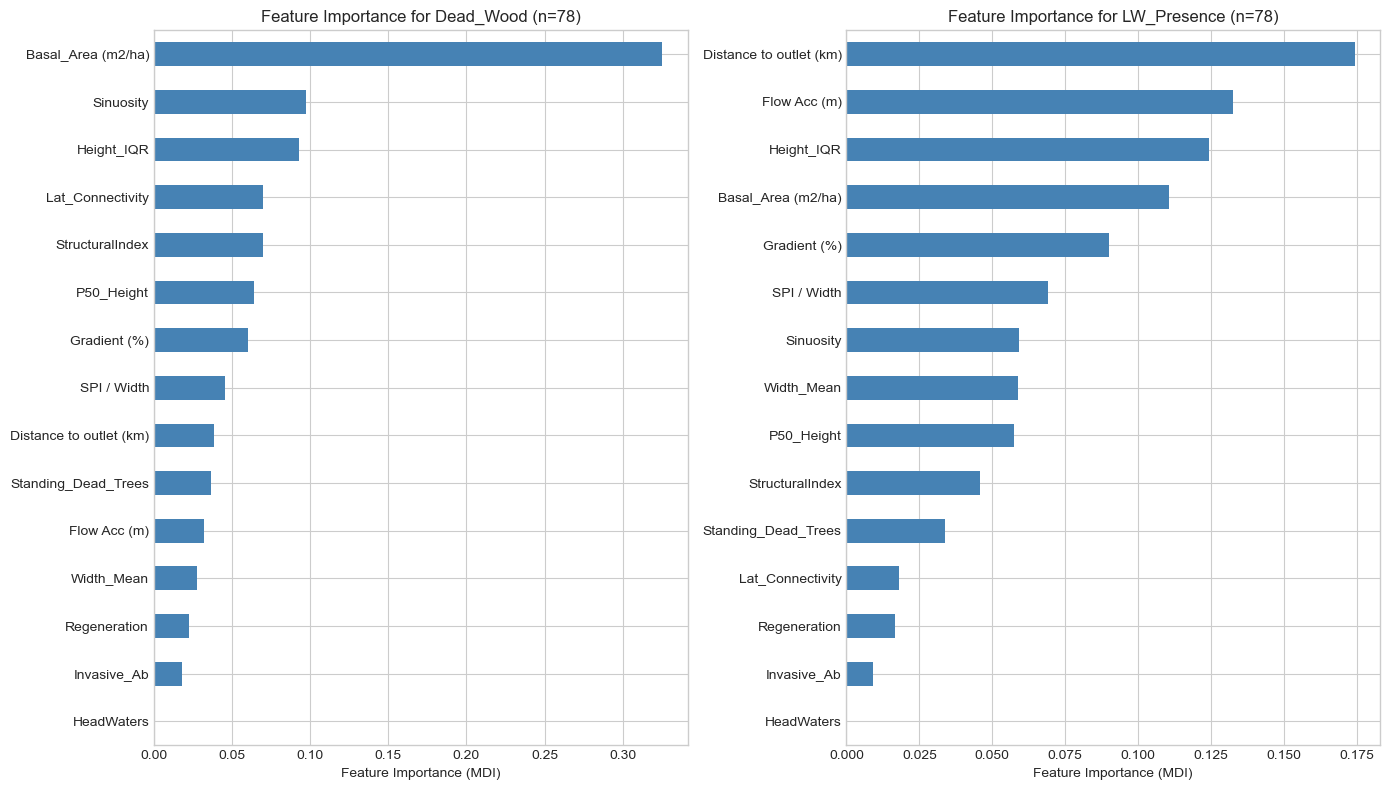

In [95]:
# Prepare feature matrix
numeric_features = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
# Remove columns that are completely empty
numeric_features = [col for col in numeric_features if df[col].notna().any()]
feature_names = numeric_features

# Results storage
importance_results = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for idx, target in enumerate(TARGET_COLS):
    # Prepare data with proper index alignment
    data_df = df[numeric_features + [target]].dropna()
    
    if len(data_df) == 0:
        print(f"Warning: No valid samples for {target}. Skipping...")
        continue
    
    X_valid = data_df[numeric_features]
    y_valid = data_df[target]
    n_samples = len(X_valid)
    
    print(f"{target}: {n_samples} valid samples")
    
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_valid, y_valid)
    
    # Get feature importances
    importances = pd.Series(rf.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)
    importance_results[target] = importances
    
    # Plot
    importances.plot(kind='barh', ax=axes[idx], color='steelblue')
    axes[idx].set_xlabel('Feature Importance (MDI)')
    axes[idx].set_title(f'Feature Importance for {target} (n={n_samples})')

plt.tight_layout()
plt.show()


In [96]:
# Compare top important features for both targets
print("Top 5 Important Features Comparison:")
print("="*60)
print(f"{'Rank':<6}{'Dead_Wood':<25}{'LW_Presence':<25}")
print("-"*60)

dw_top = importance_results['Dead_Wood'].nlargest(5)
lw_top = importance_results['LW_Presence'].nlargest(5)

for i in range(5):
    dw_feat = f"{dw_top.index[i]} ({dw_top.iloc[i]:.3f})"
    lw_feat = f"{lw_top.index[i]} ({lw_top.iloc[i]:.3f})"
    print(f"{i+1:<6}{dw_feat:<25}{lw_feat:<25}")

Top 5 Important Features Comparison:
Rank  Dead_Wood                LW_Presence              
------------------------------------------------------------
1     Basal_Area (m2/ha) (0.325)Distance to outlet (km) (0.174)
2     Sinuosity (0.097)        Flow Acc (m) (0.133)     
3     Height_IQR (0.093)       Height_IQR (0.124)       
4     Lat_Connectivity (0.070) Basal_Area (m2/ha) (0.111)
5     StructuralIndex (0.070)  Gradient (%) (0.090)     


5-Fold Cross-Validation (GroupKFold by Reach)

Dead_Wood (n=78 samples)
Fold  R² Train    R² Test     MAE       RMSE      
--------------------------------------------------
1     0.8884      -0.0019     0.5994    0.6824    
2     0.8795      -0.0436     0.6787    0.8446    
3     0.8693      0.3857      0.6663    0.8064    
4     0.9043      -0.3758     0.8381    1.0947    
5     0.8722      0.1815      0.8500    1.0678    

Metric              Train          Test           
--------------------------------------------------
R² Mean             0.8827         0.0292         
R² Std              0.0126         0.2532         
MAE Mean            ---            0.7265         
MAE Std             ---            0.0998         
RMSE Mean           ---            0.8992         
RMSE Std            ---            0.1582         

LW_Presence (n=78 samples)
Fold  R² Train    R² Test     MAE       RMSE      
--------------------------------------------------
1     0.9239      -1.0297     0.

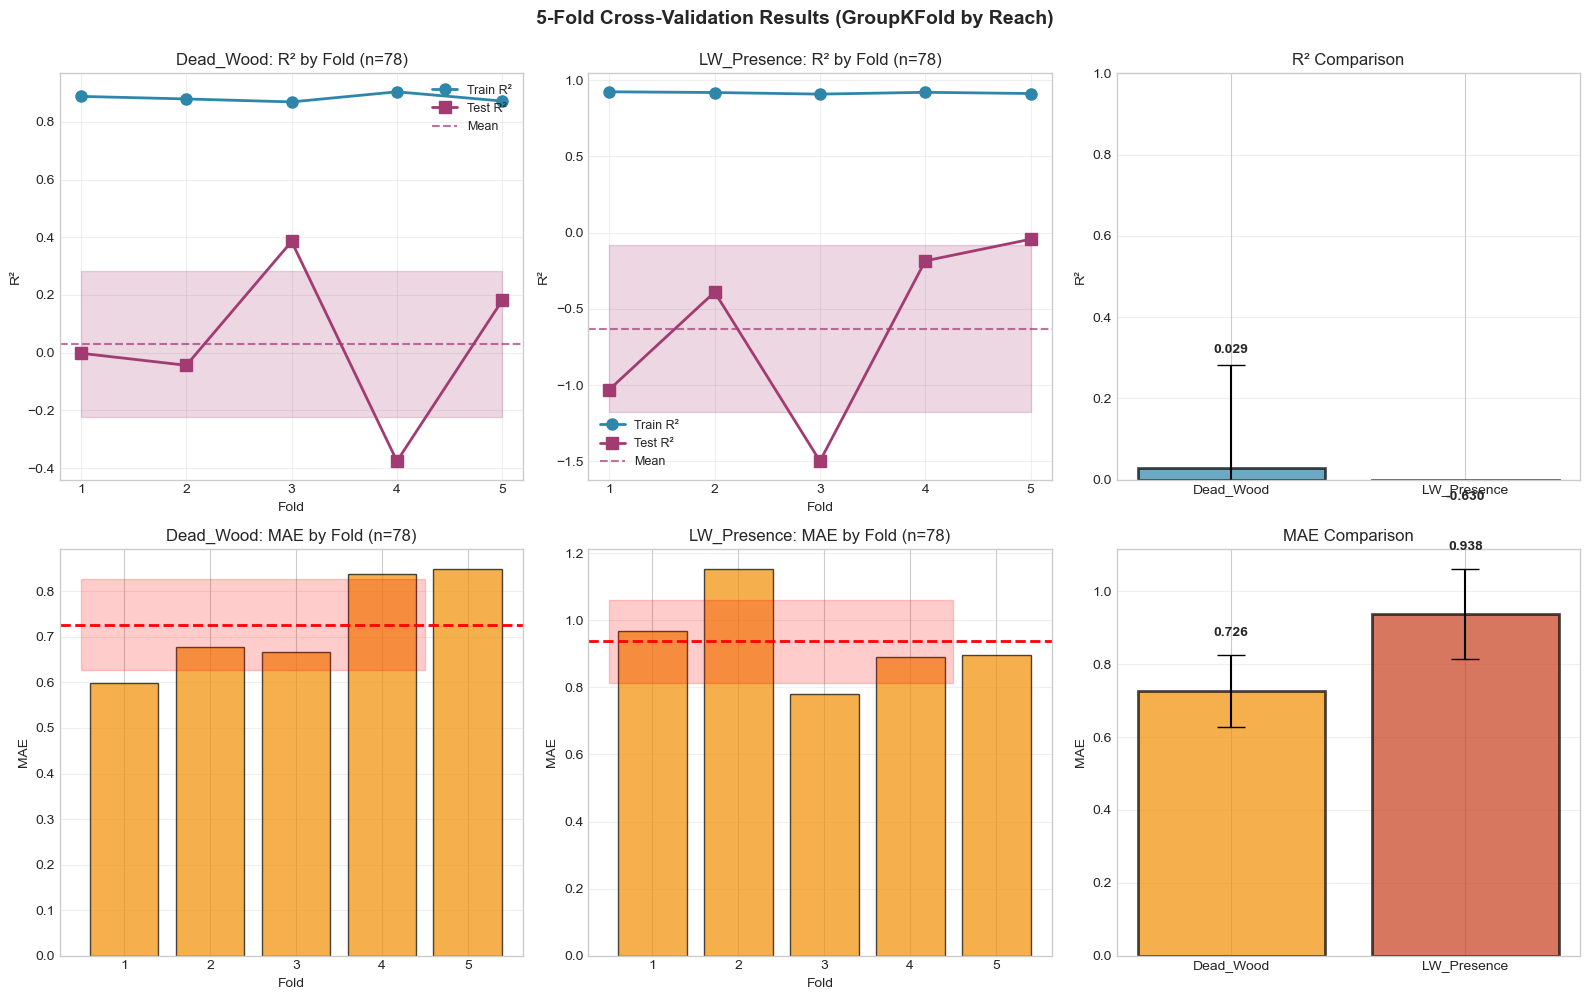

In [97]:
from sklearn.model_selection import cross_validate, GroupKFold

# Group by Reach to avoid data leakage
data_df_cv = df[numeric_features + TARGET_COLS + ['Reach']].dropna()
groups = pd.factorize(data_df_cv['Reach'])[0]
gkfold = GroupKFold(n_splits=5)

# Define scoring metrics
scoring = {
    'r2': 'r2',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mse': 'neg_mean_squared_error'
}

cv_results_all = {}

print("="*80)
print("5-Fold Cross-Validation (GroupKFold by Reach)")
print("="*80)

for target in TARGET_COLS:
    print(f"\n{target} (n={len(data_df_cv)} samples)")
    
    X = data_df_cv[numeric_features]
    y = data_df_cv[target]
    
    # Cross-validation
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    cv_results = cross_validate(rf, X, y, cv=gkfold, groups=groups, 
                                scoring=scoring, return_train_score=True)
    
    # Convert metrics to positive values
    cv_results['mae'] = -cv_results['test_neg_mae']
    cv_results['rmse'] = np.sqrt(-cv_results['test_neg_mse'])
    cv_results['train_mae'] = -cv_results['train_neg_mae']
    cv_results['train_rmse'] = np.sqrt(-cv_results['train_neg_mse'])
    
    cv_results_all[target] = cv_results
    
    # Print results by fold
    print(f"{'Fold':<6}{'R² Train':<12}{'R² Test':<12}{'MAE':<10}{'RMSE':<10}")
    print("-" * 50)
    for i in range(5):
        print(f"{i+1:<6}{cv_results['train_r2'][i]:<12.4f}{cv_results['test_r2'][i]:<12.4f}{cv_results['mae'][i]:<10.4f}{cv_results['rmse'][i]:<10.4f}")
    
    # Summary statistics
    print(f"\n{'Metric':<20}{'Train':<15}{'Test':<15}")
    print("-" * 50)
    print(f"{'R² Mean':<20}{cv_results['train_r2'].mean():<15.4f}{cv_results['test_r2'].mean():<15.4f}")
    print(f"{'R² Std':<20}{cv_results['train_r2'].std():<15.4f}{cv_results['test_r2'].std():<15.4f}")
    print(f"{'MAE Mean':<20}{'---':<15}{cv_results['mae'].mean():<15.4f}")
    print(f"{'MAE Std':<20}{'---':<15}{cv_results['mae'].std():<15.4f}")
    print(f"{'RMSE Mean':<20}{'---':<15}{cv_results['rmse'].mean():<15.4f}")
    print(f"{'RMSE Std':<20}{'---':<15}{cv_results['rmse'].std():<15.4f}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, target in enumerate(TARGET_COLS):
    cv_results = cv_results_all[target]
    folds = np.arange(1, 6)
    
    # R² by fold
    ax = axes[0, idx]
    ax.plot(folds, cv_results['train_r2'], 'o-', linewidth=2, markersize=8, 
            label='Train R²', color='#2E86AB')
    ax.plot(folds, cv_results['test_r2'], 's-', linewidth=2, markersize=8, 
            label='Test R²', color='#A23B72')
    ax.axhline(cv_results['test_r2'].mean(), color='#A23B72', linestyle='--', 
               alpha=0.7, label='Mean')
    ax.fill_between(folds, 
                    cv_results['test_r2'].mean() - cv_results['test_r2'].std(),
                    cv_results['test_r2'].mean() + cv_results['test_r2'].std(),
                    alpha=0.2, color='#A23B72')
    ax.set_xlabel('Fold')
    ax.set_ylabel('R²')
    ax.set_title(f'{target}: R² by Fold (n={len(data_df_cv)})')
    ax.set_xticks(folds)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # MAE by fold
    ax = axes[1, idx]
    ax.bar(folds, cv_results['mae'], alpha=0.7, color='#F18F01', edgecolor='black')
    ax.axhline(cv_results['mae'].mean(), color='red', linestyle='--', linewidth=2)
    ax.fill_between(folds - 0.5, 
                    cv_results['mae'].mean() - cv_results['mae'].std(),
                    cv_results['mae'].mean() + cv_results['mae'].std(),
                    alpha=0.2, color='red')
    ax.set_xlabel('Fold')
    ax.set_ylabel('MAE')
    ax.set_title(f'{target}: MAE by Fold (n={len(data_df_cv)})')
    ax.set_xticks(folds)
    ax.grid(True, alpha=0.3, axis='y')

# Summary comparison
ax = axes[0, 2]
x_pos = np.arange(len(TARGET_COLS))
r2_means = [cv_results_all[t]['test_r2'].mean() for t in TARGET_COLS]
r2_stds = [cv_results_all[t]['test_r2'].std() for t in TARGET_COLS]

bars = ax.bar(x_pos, r2_means, yerr=r2_stds, capsize=10, alpha=0.7, 
              color=['#2E86AB', '#A23B72'], edgecolor='black', linewidth=2)
ax.set_ylabel('R²')
ax.set_title('R² Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(TARGET_COLS)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

for bar, mean, std in zip(bars, r2_means, r2_stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.03, f'{mean:.3f}', 
            ha='center', fontsize=10, fontweight='bold')

# MAE comparison
ax = axes[1, 2]
mae_means = [cv_results_all[t]['mae'].mean() for t in TARGET_COLS]
mae_stds = [cv_results_all[t]['mae'].std() for t in TARGET_COLS]

bars = ax.bar(x_pos, mae_means, yerr=mae_stds, capsize=10, alpha=0.7, 
              color=['#F18F01', '#C73E1D'], edgecolor='black', linewidth=2)
ax.set_ylabel('MAE')
ax.set_title('MAE Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(TARGET_COLS)
ax.grid(True, alpha=0.3, axis='y')

for bar, mean, std in zip(bars, mae_means, mae_stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.05, f'{mean:.3f}', 
            ha='center', fontsize=10, fontweight='bold')

plt.suptitle('5-Fold Cross-Validation Results (GroupKFold by Reach)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7. Relationship Between Target Variables

This section explores **how our two main variables of interest relate to each other**. Understanding this relationship is important because:
- If they are highly correlated, they may be driven by similar underlying ecological processes
- If they differ by basin, it suggests location-specific factors influence their relationship

**How to read these plots:**
- **Left plot:** Overall scatter of Dead_Wood vs LW_Presence, colored by Basin
- **Right plot:** Same relationship but with **linear regression trend lines** for each Basin
- **r value:** Overall Pearson correlation between the two target variables

The dashed trend lines show whether the relationship direction/strength differs between the Arve, Valserine, and Rhone basins.

## 8. Summary Statistics by Location

Examining how target variables vary across different Sub-Basins.

In [98]:
# Summary by Sub_Basin
location_summary = df.groupby(['Basin', 'Sub_Basin'])[TARGET_COLS + FEATURE_COLS[:5]].agg(['mean', 'std', 'count'])
location_summary = location_summary.round(2)

# Display target variable summary
target_summary = df.groupby(['Basin', 'Sub_Basin'])[TARGET_COLS].agg(['mean', 'std', 'min', 'max', 'count'])
print("Target Variables by Location:")
print("="*80)
print(target_summary)

Target Variables by Location:
                    Dead_Wood                           LW_Presence            \
                         mean       std  min  max count        mean       std   
Basin     Sub_Basin                                                             
Arve      Arve       2.593750  0.979117  1.0  4.0    32    2.625000  1.039541   
          Giffre     2.714286  0.913874  1.0  4.0    14    3.071429  0.916875   
          Menoge     3.250000  0.957427  2.0  4.0     4    4.000000  0.000000   
Rhone     Rhone      2.300000  0.948683  1.0  4.0    10    2.800000  1.229273   
Valserine Semine     3.000000  1.264911  1.0  4.0     6    3.000000  0.894427   
          Valserine  3.166667  0.717741  2.0  4.0    12    2.833333  0.717741   

                                   
                    min max count  
Basin     Sub_Basin                
Arve      Arve        1   4    32  
          Giffre      2   4    14  
          Menoge      4   4     4  
Rhone     Rhone       1 

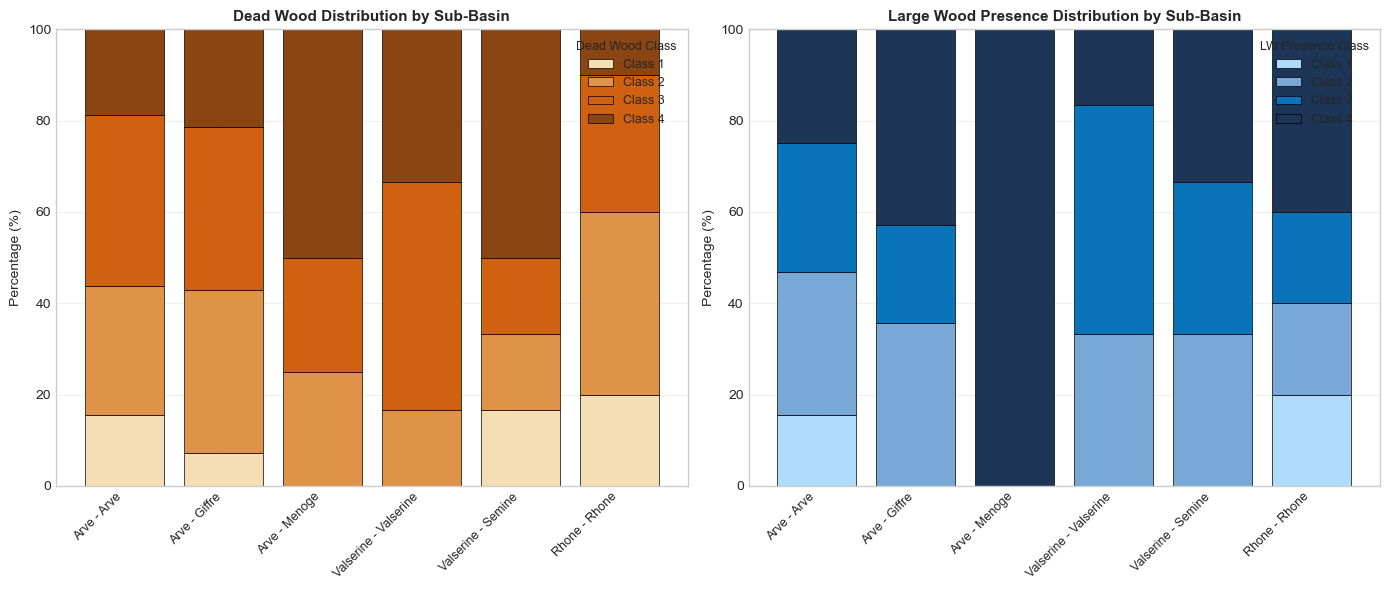

In [99]:
# Visualization: 100% Stacked Bar Charts by Sub-Basin
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_plot = df.copy()
df_plot['Location'] = df_plot['Basin'] + ' - ' + df_plot['Sub_Basin']

# Define color palette by Sub-Basin (auto-detect all sub-basins from data)
active_locations = sorted(list(df_plot['Location'].unique()))

# Color scheme: Arve (warm reds/oranges), Valserine (cool blues), Rhone (greens)
subbasin_colors = {
    'Arve - Arve': '#E63946',           # Strong red
    'Arve - Giffre': '#F77F00',         # Orange
    'Arve - Menoge': '#FCBF49',         # Orange-yellow
    'Valserine - Valserine': '#1D3557', # Deep blue
    'Valserine - Semine': '#457B9D',    # Light blue
    'Rhone - Isere': '#2D6A4F',         # Deep green
    'Rhone - Rhone': '#40916C',         # Medium green
    'Rhone - Ardeche': '#74C69D',       # Light green
}

# Fill in any missing locations with a fallback color
for loc in active_locations:
    if loc not in subbasin_colors:
        subbasin_colors[loc] = '#808080'  # Gray fallback

# Dynamic sorting: order by Basin (Arve → Valserine → Rhone), then by Sub_Basin
basin_order = {'Arve': 0, 'Valserine': 1, 'Rhone': 2}
subbasin_order = {'Arve': 0, 'Giffre': 1, 'Menoge': 2, 'Valserine': 0, 'Semine': 1, 
                  'Isere': 0, 'Rhone': 1, 'Ardeche': 2}

def location_sort_key(loc):
    """Sort function: (basin_order, subbasin_order)"""
    parts = str(loc).split(' - ')
    return (basin_order.get(parts[0], 999), subbasin_order.get(parts[1], 999))

# ============ DEAD_WOOD PLOT ============
# Create crosstab: rows=Location, columns=Dead_Wood class values (1-4), normalized to 100%
dw_crosstab = pd.crosstab(df_plot['Location'], df_plot['Dead_Wood'])
dw_crosstab.index = dw_crosstab.index.astype(str)
dw_crosstab = dw_crosstab.reindex(sorted(dw_crosstab.index, key=location_sort_key))

# Sort columns (class values) from 4 down to 1
dw_crosstab = dw_crosstab[[col for col in sorted(dw_crosstab.columns, reverse=True) if col in dw_crosstab.columns]]

# Normalize to percentages (100%)
dw_pct = dw_crosstab.div(dw_crosstab.sum(axis=1), axis=0) * 100

# Create stacked bar chart for Dead_Wood using global color palette
bottom = np.zeros(len(dw_pct))
for col in sorted(dw_pct.columns):  # 1 to 4
    axes[0].bar(range(len(dw_pct)), dw_pct[col], bottom=bottom, 
                label=f'Class {int(col)}', color=dw_class_colors.get(col, '#888888'), 
                edgecolor='black', linewidth=0.5)
    bottom += dw_pct[col].values

axes[0].set_xticks(range(len(dw_pct)))
axes[0].set_xticklabels(dw_pct.index, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Percentage (%)', fontsize=10)
axes[0].set_title('Dead Wood Distribution by Sub-Basin', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].legend(loc='upper right', fontsize=9, title='Dead Wood Class', title_fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ============ LW_PRESENCE PLOT ============
# Create crosstab: rows=Location, columns=LW_Presence class values, normalized to 100%
lw_crosstab = pd.crosstab(df_plot['Location'], df_plot['LW_Presence'])
lw_crosstab.index = lw_crosstab.index.astype(str)
lw_crosstab = lw_crosstab.reindex(sorted(lw_crosstab.index, key=location_sort_key))  # Use the same dynamic sorting

# Sort columns (class values) from 4 down to 1
lw_crosstab = lw_crosstab[[col for col in sorted(lw_crosstab.columns, reverse=True) if col in lw_crosstab.columns]]

# Normalize to percentages (100%)
lw_pct = lw_crosstab.div(lw_crosstab.sum(axis=1), axis=0) * 100

# Create stacked bar chart for LW_Presence using global color palette
bottom = np.zeros(len(lw_pct))
for col in sorted(lw_pct.columns):  # 1 to 4
    axes[1].bar(range(len(lw_pct)), lw_pct[col], bottom=bottom, 
                label=f'Class {int(col)}', color=lw_class_colors.get(col, '#888888'), 
                edgecolor='black', linewidth=0.5)
    bottom += lw_pct[col].values

axes[1].set_xticks(range(len(lw_pct)))
axes[1].set_xticklabels(lw_pct.index, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Percentage (%)', fontsize=10)
axes[1].set_title('Large Wood Presence Distribution by Sub-Basin', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper right', fontsize=9, title='LW Presence Class', title_fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature Value Ranges Associated with Target Values 1-4

This section identifies which **values and ranges** of the top 8 most important features 
are associated with different target values (1-4).

This is useful for understanding:
- What feature ranges characterize each target category
- Whether there are clear value thresholds that distinguish target classes
- How feature distributions shift across target values

**Visualizations:**
- **Violin plots:** Show full distribution of each feature for each target value
- **Heatmap:** Displays median feature values across target categories
- **Distribution plots:** Highlight how features concentrate at different target levels

In [100]:
# Get top 8 most important features for EACH target variable separately
top_n = 8

# Get importance scores
dw_importance = importance_results['Dead_Wood'].sort_values(ascending=False)
lw_importance = importance_results['LW_Presence'].sort_values(ascending=False)

# Create separate top 8 lists for each target
top_8_features_dw = dw_importance.head(top_n).index.tolist()
top_8_features_lw = lw_importance.head(top_n).index.tolist()

print(f"Top {top_n} Most Important Features for Dead_Wood:")
print("="*50)
for i, feat in enumerate(top_8_features_dw, 1):
    print(f"{i}. {feat}: {dw_importance[feat]:.4f}")

print(f"\n\nTop {top_n} Most Important Features for LW_Presence:")
print("="*50)
for i, feat in enumerate(top_8_features_lw, 1):
    print(f"{i}. {feat}: {lw_importance[feat]:.4f}")

Top 8 Most Important Features for Dead_Wood:
1. Basal_Area (m2/ha): 0.3253
2. Sinuosity: 0.0975
3. Height_IQR: 0.0927
4. Lat_Connectivity: 0.0699
5. StructuralIndex: 0.0698
6. P50_Height: 0.0641
7. Gradient (%): 0.0602
8. SPI / Width: 0.0454


Top 8 Most Important Features for LW_Presence:
1. Distance to outlet (km): 0.1743
2. Flow Acc (m): 0.1326
3. Height_IQR: 0.1243
4. Basal_Area (m2/ha): 0.1106
5. Gradient (%): 0.0901
6. SPI / Width: 0.0690
7. Sinuosity: 0.0592
8. Width_Mean: 0.0589


In [101]:
# Prepare data for Dead_Wood analysis
df_dead_wood = df[df['Dead_Wood'].isin([1, 2, 3, 4])].copy()
df_dead_wood['Dead_Wood_Category'] = df_dead_wood['Dead_Wood'].astype(str)

print(f"Dead_Wood data prepared:")
print(f"  Total samples: {len(df_dead_wood)}")
print(f"  Dead_Wood categories: {sorted(df_dead_wood['Dead_Wood'].unique())}")

# Prepare data for LW_Presence analysis
df_lw = df[df['LW_Presence'].isin([1, 2, 3, 4])].copy()
df_lw['LW_Presence_Category'] = df_lw['LW_Presence'].astype(str)

print(f"\nLW_Presence data prepared:")
print(f"  Total samples: {len(df_lw)}")
print(f"  LW_Presence categories: {sorted(df_lw['LW_Presence'].unique())}")

Dead_Wood data prepared:
  Total samples: 78
  Dead_Wood categories: [1.0, 2.0, 3.0, 4.0]

LW_Presence data prepared:
  Total samples: 78
  LW_Presence categories: [1, 2, 3, 4]


### Dead_Wood Analysis: Distribution of Top Features by Dead_Wood Value (1-4)

In [102]:
# Summary statistics for Dead_Wood analysis
print("\n" + "="*80)
print("SUMMARY: Feature Statistics by Dead_Wood Value")
print("="*80)

for feat in top_8_features_dw:
    print(f"\n{feat}:")
    print("-" * 60)
    summary = df_dead_wood.groupby('Dead_Wood_Category')[feat].agg(['count', 'mean', 'std', 'min', 'max'])
    print(summary.round(2))


SUMMARY: Feature Statistics by Dead_Wood Value

Basal_Area (m2/ha):
------------------------------------------------------------
                    count   mean   std    min    max
Dead_Wood_Category                                  
1.0                     9  17.63  8.58   7.24  36.61
2.0                    22  28.44  5.82  19.63  42.95
3.0                    28  33.93  9.20  21.19  54.15
4.0                    19  34.23  9.50  17.06  56.91

Sinuosity:
------------------------------------------------------------
                    count  mean   std   min   max
Dead_Wood_Category                               
1.0                     9  1.31  0.44  1.06  2.08
2.0                    22  1.26  0.21  1.06  1.82
3.0                    28  1.23  0.16  1.07  1.82
4.0                    19  1.29  0.15  1.06  1.66

Height_IQR:
------------------------------------------------------------
                    count  mean   std  min   max
Dead_Wood_Category                              
1.0    

In [103]:
# Helper function to format p-values for publication-quality output
def format_pvalue(p):
    """
    Format p-value based on magnitude:
    - p < 0.001 → "p < 0.001"
    - 0.001 ≤ p < 0.01 → 3 decimals (e.g., "p = 0.005")
    - 0.01 ≤ p < 0.1 → 3 decimals (e.g., "p = 0.058")
    - p ≥ 0.1 → 2 decimals (e.g., "p = 0.12")
    """
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return f"p = {p:.3f}"
    elif p < 0.1:
        return f"p = {p:.3f}"
    else:
        return f"p = {p:.2f}"


In [104]:
# Statistical tests for Dead_Wood: Kruskal-Wallis and Spearman correlation
from scipy.stats import kruskal, spearmanr

print('\n' + '='*100)
print('STATISTICAL TESTS FOR DEAD_WOOD - Top 8 Features')
print('='*100)
print(f'\nKruskal-Wallis (H-test) - Tests if distributions differ across Dead_Wood Classes (1-4)')
print(f'Spearman rho - Correlation with Dead_Wood ordinal variable (1-4)')
print('\n' + '-'*100)
print(f'{"Feature":<30} {"Kruskal-Wallis H":<20} {"p-value (KW)":<18} {"Spearman rho":<18} {"p-value (Spearman)":<18}')
print('-'*100)

stats_dw = []

for feat in top_8_features_dw:
    # Prepare data
    feat_data = df_dead_wood[[feat, 'Dead_Wood_Category']].dropna()
    
    if len(feat_data) > 0:
        # Kruskal-Wallis test
        groups = [feat_data[feat_data['Dead_Wood_Category'] == str(i)][feat].values 
                  for i in [1, 2, 3, 4]]
        groups = [g for g in groups if len(g) > 0]  # Remove empty groups
        
        if len(groups) > 1:
            h_stat, kw_pvalue = kruskal(*groups)
        else:
            h_stat, kw_pvalue = np.nan, np.nan
        
        # Spearman correlation with ordinal Dead_Wood
        dead_wood_numeric = pd.to_numeric(feat_data['Dead_Wood_Category'], errors='coerce')
        # Remove any NaN values that resulted from conversion
        valid_mask = ~(dead_wood_numeric.isna() | feat_data[feat].isna())
        rho, spear_pvalue = spearmanr(feat_data[feat][valid_mask], dead_wood_numeric[valid_mask])
        
        stats_dw.append({
            'Feature': feat,
            'Kruskal-Wallis H': h_stat,
            'KW p-value': kw_pvalue,
            'Spearman rho': rho,
            'Spearman p-value': spear_pvalue
        })
        
        print(f'{feat:<30} {h_stat:<20.4f} {kw_pvalue:<18.4e} {rho:<18.4f} {spear_pvalue:<18.4e}')

# Create DataFrame for better visualization
stats_dw_df = pd.DataFrame(stats_dw)
print('\n' + '='*100)
print('Summary Table:')
print(stats_dw_df.to_string(index=False))


STATISTICAL TESTS FOR DEAD_WOOD - Top 8 Features

Kruskal-Wallis (H-test) - Tests if distributions differ across Dead_Wood Classes (1-4)
Spearman rho - Correlation with Dead_Wood ordinal variable (1-4)

----------------------------------------------------------------------------------------------------
Feature                        Kruskal-Wallis H     p-value (KW)       Spearman rho       p-value (Spearman)
----------------------------------------------------------------------------------------------------
Basal_Area (m2/ha)             nan                  nan                0.4453             4.4006e-05        
Sinuosity                      nan                  nan                0.2266             4.6005e-02        
Height_IQR                     nan                  nan                0.1924             9.1406e-02        
Lat_Connectivity               nan                  nan                0.4300             8.5316e-05        
StructuralIndex                nan               

### Large Wood Presence Analysis: Distribution of Top Features by LW_Presence Value (1-4)

In [105]:
# Summary statistics for LW_Presence analysis
print("\n" + "="*80)
print("SUMMARY: Feature Statistics by LW_Presence Value")
print("="*80)

for feat in top_8_features_lw:
    print(f"\n{feat}:")
    print("-" * 60)
    summary = df_lw.groupby('LW_Presence_Category')[feat].agg(['count', 'mean', 'std', 'min', 'max'])
    print(summary.round(2))


SUMMARY: Feature Statistics by LW_Presence Value

Distance to outlet (km):
------------------------------------------------------------
                      count   mean    std   min    max
LW_Presence_Category                                  
1                         7  95.94  55.74  18.6  148.7
2                        23  79.97  46.24  22.5  137.0
3                        22  74.84  39.98  27.7  142.6
4                        26  74.93  33.01  16.2  120.3

Flow Acc (m):
------------------------------------------------------------
                      count          mean           std          min  \
LW_Presence_Category                                                   
1                         7  4.511773e+09  6.477417e+09  286583625.0   
2                        23  2.011598e+09  3.872231e+09  163251576.6   
3                        22  1.879554e+09  3.580884e+09  105850814.1   
4                        26  2.812258e+09  4.474455e+09  181901531.3   

                        

In [106]:
print('\n' + '='*80)
print('MODEL GROUPS: Dead_Wood vs LW_Presence')
print('='*80)

# Define predictors for each target variable
model_configs = {
    'Dead_Wood': {
        'target': 'Dead_Wood',
        'predictors': [
            'Basal_Area (m2/ha)',
            'P50_Height',
            'Height_IQR',
            'StructuralIndex',
            'Invasive_Ab',
            'Standing_Dead_Trees',
            'Regeneration'
        ]
    },
    'LW_Presence': {
        'target': 'LW_Presence',
        'predictors': [
            'Standing_Dead_Trees',
            'Regeneration',
            'Basal_Area (m2/ha)',
            'StructuralIndex',
            'P50_Height',
            'Dead_Wood',
            'Height_IQR',
            'Invasive_Ab',
            'Gradient (%)',
            'SPI / Width',
            'Distance to outlet (km)',
            'Sinuosity'
        ]
    }
}

# Display model configurations
for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    print(f'  Target: {config["target"]}')
    print(f'  Predictors ({len(config["predictors"])}):')
    for pred in config["predictors"]:
        print(f'    - {pred}')

# Verify available columns in dataframe
print(f'\n\nValidating predictors against available columns:')
available_cols = set(df.columns)

for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    missing = []
    available = []
    
    for pred in config["predictors"]:
        if pred in available_cols:
            available.append(pred)
        else:
            missing.append(pred)
    
    print(f'  ✓ Available: {len(available)}/{len(config["predictors"])}')
    if missing:
        print(f'  ✗ Missing: {len(missing)}')
        for col in missing:
            print(f'    - {col}')
    else:
        print(f'  ✓ All predictors available!')

print(f'\n✓ Model configurations ready for analysis')


MODEL GROUPS: Dead_Wood vs LW_Presence

Dead_Wood:
  Target: Dead_Wood
  Predictors (7):
    - Basal_Area (m2/ha)
    - P50_Height
    - Height_IQR
    - StructuralIndex
    - Invasive_Ab
    - Standing_Dead_Trees
    - Regeneration

LW_Presence:
  Target: LW_Presence
  Predictors (12):
    - Standing_Dead_Trees
    - Regeneration
    - Basal_Area (m2/ha)
    - StructuralIndex
    - P50_Height
    - Dead_Wood
    - Height_IQR
    - Invasive_Ab
    - Gradient (%)
    - SPI / Width
    - Distance to outlet (km)
    - Sinuosity


Validating predictors against available columns:

Dead_Wood:
  ✓ Available: 7/7
  ✓ All predictors available!

LW_Presence:
  ✓ Available: 12/12
  ✓ All predictors available!

✓ Model configurations ready for analysis


In [107]:
print('\n' + '='*120)
print('PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)')
print('='*120)

from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ===================== PREDICTOR TYPES =====================
predictor_types = {
    # Dead_Wood
    'Basal_Area (m2/ha)': 'continuous',
    'P50_Height': 'continuous',
    'Height_IQR': 'continuous',
    'StructuralIndex': 'continuous',
    'Invasive_Ab': 'discrete_count',
    'Standing_Dead_Trees': 'ordinal_1_4',
    'Regeneration': 'ordinal_1_4',
    # LW_Presence
    'Gradient (%)': 'continuous',
    'SPI / Width': 'continuous',
    'Distance to outlet (km)': 'continuous',
    'Sinuosity': 'continuous',
}

# ===================== HELPER FUNCTIONS =====================
def calculate_epsilon_squared(h_stat, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis
    Returns max(0, ...) to avoid negative values"""
    return max((h_stat - k + 1) / (n - k), 0)

def assign_visual_pattern(abs_rho, kw_p, eps_sq):
    """Assign visual pattern based on explicit statistical thresholds"""
    if abs_rho >= 0.50 and kw_p < 0.05 and eps_sq >= 0.08:
        return 'strong_pattern'
    elif 0.30 <= abs_rho < 0.50 and kw_p < 0.05 and eps_sq >= 0.02:
        return 'moderate_pattern'
    elif 0.10 <= abs_rho < 0.30 and (kw_p < 0.10 or eps_sq >= 0.01):
        return 'weak_pattern'
    elif abs_rho < 0.10 and kw_p > 0.05:
        return 'no_clear_pattern'
    else:
        return 'difficult_to_assess'

def get_pattern_note(pattern, abs_rho, kw_p, eps_sq, n_unique):
    """Get brief explanation for pattern assignment"""
    if pattern == 'strong_pattern':
        return 'clear monotonic gradient and/or reasonable class separation'
    elif pattern == 'moderate_pattern':
        return 'visible trend with overlap among classes'
    elif pattern == 'weak_pattern':
        return 'weak trend with substantial overlap'
    elif pattern == 'no_clear_pattern':
        return 'no clear gradient or class separation'
    else:  # difficult_to_assess
        if n_unique <= 2 or eps_sq < 0.001:
            return 'low variability or unbalanced categories'
        else:
            return 'mixed statistical signal'

def classify_evidence(kw_p, abs_rho, pattern, eps_sq):
    """Evidence classification based on Spearman + Kruskal-Wallis coherence"""
    # strong: significant with moderate-to-strong monotonicity
    if kw_p < 0.05 and abs_rho > 0.40:
        return 'strong_evidence'
    # moderate: significant with weak-to-moderate monotonicity, OR very small p with weak monotonicity
    elif kw_p < 0.05 and abs_rho > 0.20:
        return 'moderate_evidence'
    elif (kw_p < 0.10 or abs_rho > 0.15) and eps_sq > 0.01:
        return 'moderate_evidence'
    # weak: suggestive signal but not quite reaching moderate threshold
    elif kw_p < 0.10 or abs_rho > 0.15:
        return 'weak_evidence'
    else:
        return 'ambiguous_evidence'

print(f'\n✓ Framework configured:')
print(f'  - Spearman rank correlation (monotonic association)')
print(f'  - Kruskal-Wallis H-test (group differences)')
print(f'  - Epsilon-squared effect size (non-parametric)')
print(f'  - Ranking based on Spearman ρ + Kruskal p-value')

# ==================== DEAD_WOOD MODEL ====================
print(f'\n' + '='*120)
print('DEAD_WOOD MODEL: Univariate Predictor Ranking')
print('='*120)

dead_wood_response = 'Dead_Wood'
dead_wood_preds = ['Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex', 
                    'Invasive_Ab', 'Standing_Dead_Trees', 'Regeneration']

dead_wood_preds_avail = [p for p in dead_wood_preds if p in df.columns]
df_dw = df[[dead_wood_response] + dead_wood_preds_avail].dropna()

print(f'\n✓ Analyzing {len(dead_wood_preds_avail)} predictors | {len(df_dw)} complete observations')
print(f'  Predictors: {", ".join(dead_wood_preds_avail)}')

results_dw = []

for pred in dead_wood_preds_avail:
    X = df_dw[pred].values
    y = df_dw[dead_wood_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score: transparent formula combining monotonicity + group separation
    # score = (|rho| × 10) + (-log10(Kruskal_p) × 5)
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_dw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_dw = pd.DataFrame(results_dw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_dw['Ranking_position'] = range(1, len(df_rank_dw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_dw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_dw = get_output_path('PASO3_Ranking_Dead_Wood.csv')
# Reorder columns for final export
col_order_dw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p', 
                 'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern', 
                 'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_dw[col_order_dw].to_csv(path_dw, index=False)
print(f'\n✓ Exported to: {path_dw}')

# ==================== LW_PRESENCE MODEL ====================
print(f'\n' + '='*120)
print('LW_PRESENCE MODEL: Univariate Predictor Ranking')
print('='*120)

lw_response = 'LW_Presence'
lw_preds = ['Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'StructuralIndex',
            'P50_Height', 'Height_IQR', 'Invasive_Ab', 'Gradient (%)', 'SPI / Width',
            'Distance to outlet (km)', 'Sinuosity', 'Dead_Wood']

lw_preds_avail = [p for p in lw_preds if p in df.columns]
df_lw = df[[lw_response] + lw_preds_avail].dropna()

print(f'\n✓ Analyzing {len(lw_preds_avail)} predictors | {len(df_lw)} complete observations')
print(f'  Predictors: {", ".join(lw_preds_avail)}')

results_lw = []

for pred in lw_preds_avail:
    X = df_lw[pred].values
    y = df_lw[lw_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_lw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_lw = pd.DataFrame(results_lw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_lw['Ranking_position'] = range(1, len(df_rank_lw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_lw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_lw = get_output_path('PASO3_Ranking_LW_Presence.csv')
col_order_lw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p',
                'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern',
                'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_lw[col_order_lw].to_csv(path_lw, index=False)
print(f'\n✓ Exported to: {path_lw}')

# ===================== SUMMARY & METHODOLOGY =====================
print(f'\n' + '='*120)
print('RANKING METHODOLOGY & SUMMARY')
print('='*120)

print(f'\n✓ RANKING SCORE FORMULA:')
print(f'  score = (|Spearman_rho| × 10) + (-log10(Kruskal_p) × 5)')
print(f'\n  Rationale:')
print(f'    - First term: weights monotonic correlation strength [0, 10]')
print(f'    - Second term: weights group separation significance [0, ∞)')
print(f'    - Result: transparent, reproducible ordering by evidence strength')
print(f'\n  This is NOT a formal inferential statistic.')
print(f'  It serves only to rank predictors by univariate association with targets.')

print(f'\n✓ TOP PREDICTORS FOR DEAD_WOOD:')
for i, row in df_rank_dw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ TOP PREDICTORS FOR LW_PRESENCE:')
for i, row in df_rank_lw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ EXPORTS COMPLETED:')
print(f'  - {path_dw.name}')
print(f'  - {path_lw.name}')


PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)

✓ Framework configured:
  - Spearman rank correlation (monotonic association)
  - Kruskal-Wallis H-test (group differences)
  - Epsilon-squared effect size (non-parametric)
  - Ranking based on Spearman ρ + Kruskal p-value

DEAD_WOOD MODEL: Univariate Predictor Ranking

✓ Analyzing 7 predictors | 78 complete observations
  Predictors: Basal_Area (m2/ha), P50_Height, Height_IQR, StructuralIndex, Invasive_Ab, Standing_Dead_Trees, Regeneration

✓ Ranking summary:
 Ranking_position           Predictor Predictor_type  Spearman_rho  Kruskal_p     Evidence_class
                1  Basal_Area (m2/ha)     continuous      0.445318   0.000151    strong_evidence
                2 Standing_Dead_Trees    ordinal_1_4      0.403867   0.005430    strong_evidence
                3          Height_IQR     continuous      0.192447   0.011396  moderate_evidence
                4     StructuralIndex     continuous      0.193904   0.317908      weak_evi


PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)

✓ Total predictors: 20
✓ Predictors: ['Id_RipUnit', 'Id_Reach', 'Sub_Basin', 'Reach', 'Bank', 'Lentgh (m)', 'Sinuosity', 'Lat_Connectivity', 'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Standing_Dead_Trees', 'Regeneration', 'Width_Mean', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'Invasive_Ab', 'StructuralIndex', 'Flow Acc (m)']

Dead_Wood values in data: [1.0, 2.0, 3.0, 4.0]
LW_Presence values in data: [1, 2, 3, 4]

Generating boxplots for Dead_Wood...


ValueError: List of boxplot statistics and `positions` values must have same the length

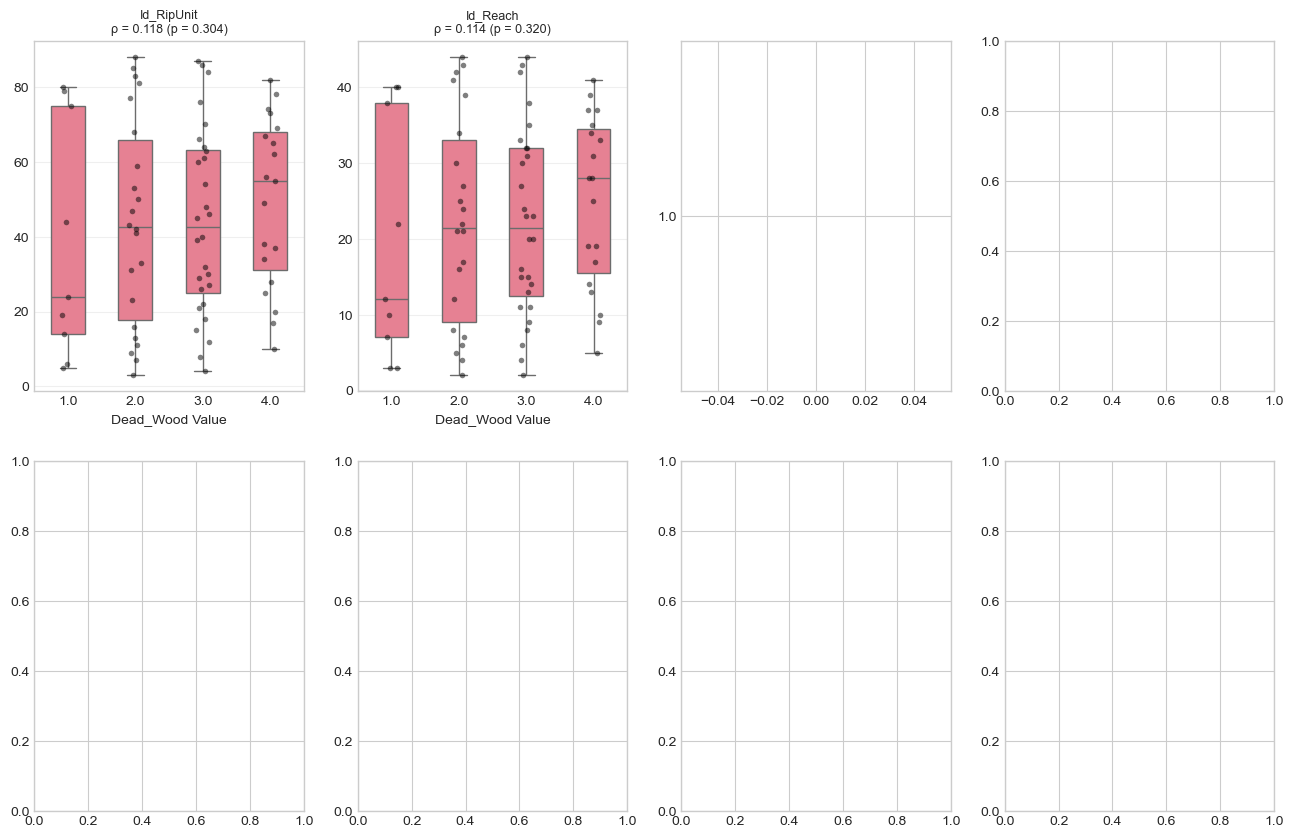

In [109]:
print('\n' + '='*120)
print('PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)')
print('='*120)

from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# BOXPLOTS: Predictor Distributions by Target Variable
# ============================================================================

# Get list of predictors (exclude target variables and identifiers)
exclude_cols = {'Dead_Wood', 'LW_Presence', 'Basin', 'RipUnit', 'RU', 'Code', 
                'Latitude', 'Longitude', 'Altitude', 'HeadWaters'}
predictors = [col for col in df.columns if col not in exclude_cols]

print(f"\n✓ Total predictors: {len(predictors)}")
print(f"✓ Predictors: {predictors}\n")

# Determine order values based on actual data
dw_order = sorted(df[dead_wood_response].dropna().unique())
lw_order = sorted(df[lw_response].dropna().unique())

print(f"Dead_Wood values in data: {dw_order}")
print(f"LW_Presence values in data: {lw_order}\n")

# Create boxplots for Dead_Wood
print("Generating boxplots for Dead_Wood...")
fig_dw, axes_dw = plt.subplots(2, 4, figsize=(16, 10))
axes_dw = axes_dw.flatten()

for idx, pred in enumerate(predictors[:8]):
    if idx >= len(axes_dw):
        break
    
    plot_data = df[[dead_wood_response, pred]].dropna()
    
    if len(plot_data) > 0:
        sns.boxplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[idx],
                   order=dw_order, width=0.5)
        sns.stripplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[idx],
                     order=dw_order, size=4, alpha=0.5, color='black', jitter=True)
        
        # Calculate correlation
        rho, p_val = spearmanr(plot_data[pred], plot_data[dead_wood_response])
        axes_dw[idx].set_title(f'{pred}\nρ = {rho:.3f} (p = {p_val:.3f})', fontsize=9)
        axes_dw[idx].set_xlabel('Dead_Wood Value')
        axes_dw[idx].set_ylabel('')
        axes_dw[idx].grid(axis='y', alpha=0.3)

# Hide unused axes
for idx in range(len(predictors[:8]), len(axes_dw)):
    axes_dw[idx].set_visible(False)

plt.suptitle('Dead_Wood: Boxplot Distribution by Predictor', fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(get_output_path('boxplots_dead_wood.png', subfolder='figures'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dead_Wood boxplots created\n")

# Create boxplots for LW_Presence
print("Generating boxplots for LW_Presence...")
fig_lw, axes_lw = plt.subplots(2, 4, figsize=(16, 10))
axes_lw = axes_lw.flatten()

for idx, pred in enumerate(predictors[:8]):
    if idx >= len(axes_lw):
        break
    
    plot_data = df[[lw_response, pred]].dropna()
    
    if len(plot_data) > 0:
        sns.boxplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[idx],
                   order=lw_order, width=0.5)
        sns.stripplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[idx],
                     order=lw_order, size=4, alpha=0.5, color='black', jitter=True)
        
        # Calculate correlation
        rho, p_val = spearmanr(plot_data[pred], plot_data[lw_response])
        axes_lw[idx].set_title(f'{pred}\nρ = {rho:.3f} (p = {p_val:.3f})', fontsize=9)
        axes_lw[idx].set_xlabel('LW_Presence Value')
        axes_lw[idx].set_ylabel('')
        axes_lw[idx].grid(axis='y', alpha=0.3)

# Hide unused axes
for idx in range(len(predictors[:8]), len(axes_lw)):
    axes_lw[idx].set_visible(False)

plt.suptitle('LW_Presence: Boxplot Distribution by Predictor', fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(get_output_path('boxplots_lw_presence.png', subfolder='figures'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ LW_Presence boxplots created\n")
print("="*120)


BOXPLOTS: Predictor Distributions Ranked by Evidence Strength

✓ Dead_Wood Model: 7 predictors


UnboundLocalError: local variable 'boxprops' referenced before assignment

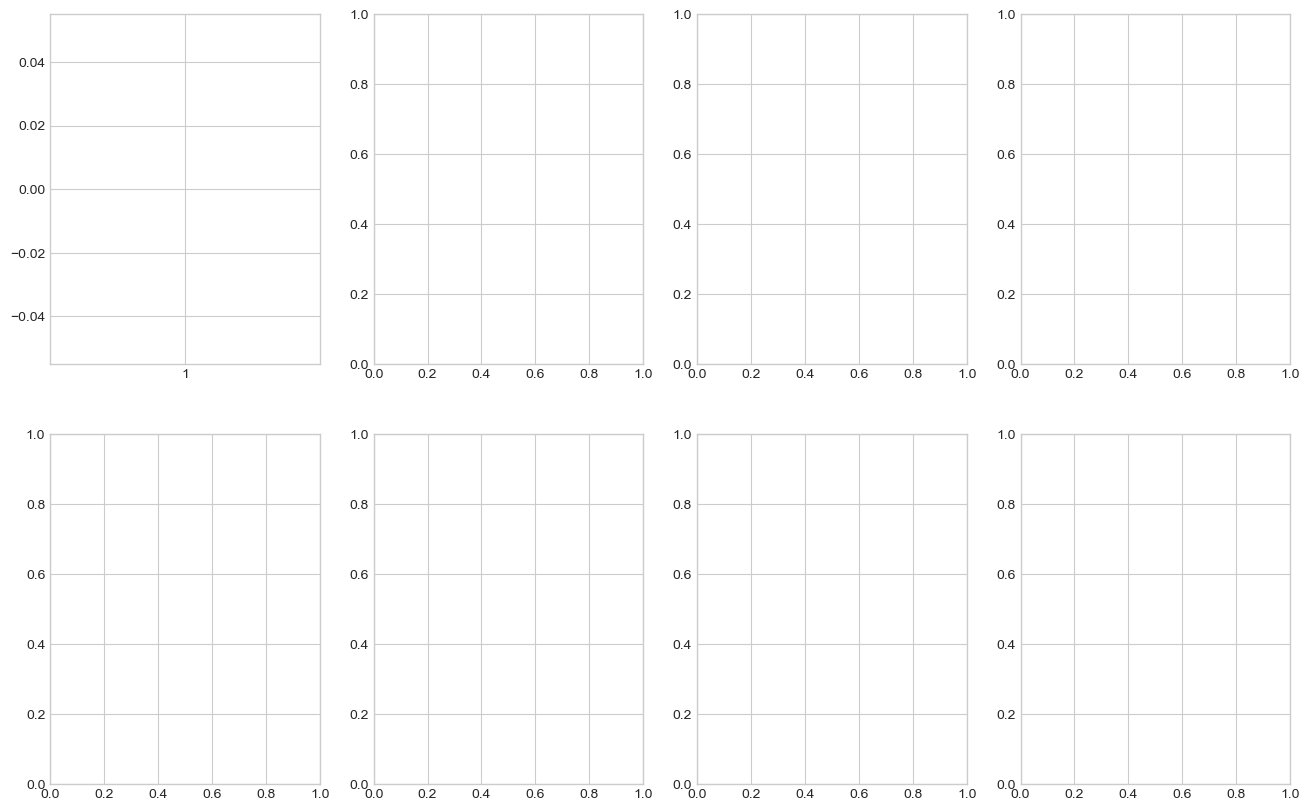

In [ ]:

# ===================== PASO 3 VISUALIZATION: BOXPLOTS BY RANKING =====================
print('\n' + '='*120)
print('BOXPLOTS: Predictor Distributions Ranked by Evidence Strength')
print('='*120)

# ==================== DEAD_WOOD BOXPLOTS ====================
print(f'\n✓ Dead_Wood Model: {len(df_rank_dw)} predictors')

# Variable name mapping for better display with units
var_name_map = {
    'Standing_Dead_Trees': 'Standing Dead Trees (m)',
    'Invasive_Ab': 'Invasive sp',
    'P50_Height': 'Height p50 (m)',
}

# Build palette list for Dead_Wood (values 1-4)
dw_palette_for_boxplot = [dw_class_colors.get(i, '#cccccc') for i in [1, 2, 3, 4]]

fig_dw, axes_dw = plt.subplots(2, 4, figsize=(16, 10))
axes_dw = axes_dw.flatten()

ax_idx = 0  # Separate index for axes
for i, row in df_rank_dw.iterrows():
    if ax_idx >= len(axes_dw):
        break
    
    pred = row['Predictor']
    
    # Skip Height_IQR
    if pred == 'Height_IQR':
        continue
    
    rho = row['Spearman_rho']
    p_spear = row['Spearman_p']
    p_kw = row['Kruskal_p']
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    
    # Prepare data
    plot_data = df[[dead_wood_response, pred]].dropna()
    n_samples = len(plot_data)
    
    if n_samples > 0:
        # Create boxplot with palette
        sns.boxplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[ax_idx],
                   palette=dw_palette_for_boxplot, order=[1, 2, 3, 4],
                   width=0.6, linewidth=1.5, patch_artist=True)
        
        # Overlay individual points
        sns.stripplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[ax_idx],
                     order=[1, 2, 3, 4], size=5, alpha=0.6,
                     color='black', jitter=True, edgecolor='gray', linewidth=0.5)
        
        axes_dw[ax_idx].set_xlabel('Dead_Wood Value (1-4)', fontsize=9)
        axes_dw[ax_idx].set_ylabel(pred, fontsize=9)
        
        # Format p-values with <0.001 threshold
        spear_p_str = '<0.001' if p_spear < 0.001 else f'{p_spear:.3f}'
        kw_p_str = '<0.001' if p_kw < 0.001 else f'{p_kw:.3f}'
        
        # Get formatted variable name (with units) or default to pred with dashes replaced by spaces
        pred_display = var_name_map.get(pred, pred.replace('_', ' '))
        
        # Set title with variable name and statistics on two lines
        title_text = f'{pred_display}\nρ = {rho:.3f} ({spear_p_str}) | KW p = {kw_p_str} | n = {n_samples}'
        axes_dw[ax_idx].set_title(title_text, fontsize=9, fontweight='bold')
        axes_dw[ax_idx].grid(axis='y', alpha=0.3)
        
        ax_idx += 1  # Only increment when actually plotting

# Hide unused axes
for idx in range(ax_idx, len(axes_dw)):
    axes_dw[idx].set_visible(False)

plt.suptitle(' ', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f'\n✓ Dead_Wood boxplots created: {len(df_rank_dw)} predictors displayed')

# ==================== LW_PRESENCE BOXPLOTS ====================
print(f'\n✓ LW_Presence Model: {len(df_rank_lw)} predictors')

# Build palette list for LW_Presence (values 1-4)
lw_palette_for_boxplot = [lw_class_colors.get(i, '#cccccc') for i in [1, 2, 3, 4]]

fig_lw, axes_lw = plt.subplots(3, 4, figsize=(16, 12))
axes_lw = axes_lw.flatten()

ax_idx = 0  # Separate index for axes
for i, row in df_rank_lw.iterrows():
    if ax_idx >= len(axes_lw):
        break
    
    pred = row['Predictor']
    
    # Skip Height_IQR
    if pred == 'Height_IQR':
        continue
    
    rho = row['Spearman_rho']
    p_spear = row['Spearman_p']
    p_kw = row['Kruskal_p']
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    
    # Prepare data
    plot_data = df[[lw_response, pred]].dropna()
    n_samples = len(plot_data)
    
    if n_samples > 0:
        # Create boxplot with palette
        sns.boxplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[ax_idx],
                   palette=lw_palette_for_boxplot, order=[1, 2, 3, 4],
                   width=0.6, linewidth=1.5, patch_artist=True)
        
        # Overlay individual points
        sns.stripplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[ax_idx],
                     order=[1, 2, 3, 4], size=5, alpha=0.6,
                     color='black', jitter=True, edgecolor='gray', linewidth=0.5)
        
        axes_lw[ax_idx].set_xlabel('LW_Presence Value (1-4)', fontsize=9)
        axes_lw[ax_idx].set_ylabel(pred, fontsize=9)
        
        # Format p-values
        spear_p_str = '<0.001' if p_spear < 0.001 else f'{p_spear:.3f}'
        kw_p_str = '<0.001' if p_kw < 0.001 else f'{p_kw:.3f}'
        
        # Get formatted variable name (with units) or default to pred with dashes replaced by spaces
        pred_display = var_name_map.get(pred, pred.replace('_', ' '))
        
        # Set title with variable name and statistics on two lines
        title_text = f'{pred_display}\nρ = {rho:.3f} ({spear_p_str}) | KW p = {kw_p_str} | n = {n_samples}'
        axes_lw[ax_idx].set_title(title_text, fontsize=9, fontweight='bold')
        axes_lw[ax_idx].grid(axis='y', alpha=0.3)
        
        ax_idx += 1  # Only increment when actually plotting

# Hide unused axes
for idx in range(ax_idx, len(axes_lw)):
    axes_lw[idx].set_visible(False)

plt.suptitle(' ', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f'\n✓ LW_Presence boxplots created: {len(df_rank_lw)} predictors displayed')

print(f'\n✓ All visualizations completed. Compare distributions with ranking evidence.')


In [ ]:
print('\n' + '='*120)
print('PASO 5: FINAL PREDICTOR SELECTION FOR MULTIVARIABLE MODELS')
print('='*120)

# ==================== DEFINE PREDICTOR SETS ====================
dead_wood_preds_set = {
    'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex',
    'Invasive_Ab', 'Standing_Dead_Trees', 'Regeneration'
}

lw_presence_preds_set = {
    'Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'StructuralIndex',
    'P50_Height', 'Height_IQR', 'Invasive_Ab', 'Gradient (%)', 'SPI / Width',
    'Distance to outlet (km)', 'Sinuosity', 'Dead_Wood'
}

# ==================== HELPER FUNCTIONS FOR DECISION LOGIC ====================
def assign_ecological_role(pred, response_type):
    """Assign ecological/geomorphological role to predictor"""
    forest_structure = {'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex',
                        'Standing_Dead_Trees', 'Regeneration'}
    invasive_pressure = {'Invasive_Ab'}
    availability_signal = {'Dead_Wood', 'Standing_Dead_Trees'}
    geomorph = {'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Sinuosity'}
    
    if pred in invasive_pressure:
        return 'human_pressure'
    elif response_type == 'LW_Presence' and pred in availability_signal:
        return 'wood_availability'
    elif response_type == 'LW_Presence' and pred in geomorph:
        return 'geomorphological_control'
    elif pred in forest_structure:
        return 'forest_structure'
    else:
        return 'other'

def assign_selection_decision(row, response_type):
    """
    Decision logic based on:
    - Ranking position
    - Evidence class
    - Visual pattern
    - Ecological role
    - Conceptual/ecological priority for key predictors
    """
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    pattern = row['Visual_pattern']
    pred = row['Predictor']
    role = assign_ecological_role(pred, response_type)
    
    # ============ LW_PRESENCE SPECIFIC LOGIC ============
    if response_type == 'LW_Presence':
        # CORE candidates: Dead_Wood and SPI / Width only
        if pred in ['Dead_Wood', 'SPI / Width']:
            return pd.Series({'Selection_priority': 'core_candidate', 'Selected_for_multivariable_model': 'yes'})
        
        # SECONDARY candidates: Standing_Dead_Trees, Distance to outlet, Sinuosity, Gradient (%)
        if pred in ['Standing_Dead_Trees', 'Distance to outlet (km)', 'Sinuosity', 'Gradient (%)']:
            return pd.Series({'Selection_priority': 'secondary_candidate', 'Selected_for_multivariable_model': 'maybe'})
        
        # NOT RETAINED INITIALLY: other forest structure and pressure variables
        if pred in ['Regeneration', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex', 'Invasive_Ab']:
            return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})
    
    # ============ DEAD_WOOD SPECIFIC LOGIC ============
    if response_type == 'Dead_Wood':
        # CORE candidates: only Basal_Area and Standing_Dead_Trees
        if pred in ['Basal_Area (m2/ha)', 'Standing_Dead_Trees']:
            return pd.Series({'Selection_priority': 'core_candidate', 'Selected_for_multivariable_model': 'yes'})
        
        # SECONDARY candidates: Regeneration, Height_IQR, StructuralIndex
        if pred in ['Regeneration', 'Height_IQR', 'StructuralIndex']:
            return pd.Series({'Selection_priority': 'secondary_candidate', 'Selected_for_multivariable_model': 'maybe'})
        
        # NOT RETAINED: Invasive_Ab, P50_Height
        if pred in ['Invasive_Ab', 'P50_Height']:
            return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})
    
    # Default: not retained initially
    return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})

# ==================== DEAD_WOOD MODEL - SELECTION TABLE ====================
print(f'\n' + '='*120)
print('DEAD_WOOD MODEL: Predictors Selection')
print('='*120)

# Filter to only predictors in our defined set
df_dw_filtered = df_rank_dw[df_rank_dw['Predictor'].isin(dead_wood_preds_set)].copy()

# Add decision columns
df_dw_filtered['Ecological_role'] = df_dw_filtered.apply(
    lambda row: assign_ecological_role(row['Predictor'], 'Dead_Wood'), axis=1
)

df_dw_filtered[['Selection_priority', 'Selected_for_multivariable_model']] = df_dw_filtered.apply(
    lambda row: assign_selection_decision(row, 'Dead_Wood'), axis=1
)

# Add redundancy notes (from visual inspection - can be enriched if formal redundancy analysis available)
redundancy_notes_dw = {
    'Standing_Dead_Trees': 'potential redundancy with Regeneration (both structural)',
    'Regeneration': 'potential redundancy with Standing_Dead_Trees',
    'Height_IQR': 'structural complexity, complements P50_Height',
    'P50_Height': 'core structural metric',
    'StructuralIndex': 'integrative structural measure',
    'Basal_Area (m2/ha)': 'biomass proxy, core predictor',
    'Invasive_Ab': 'unique human pressure signal',
}

df_dw_filtered['Redundancy_note'] = df_dw_filtered['Predictor'].map(
    redundancy_notes_dw
).fillna('')

# Reorder columns
col_order = ['Predictor', 'Predictor_type', 'Ranking_position', 'Evidence_class', 
             'Visual_pattern', 'Redundancy_note', 'Ecological_role',
             'Selected_for_multivariable_model', 'Selection_priority', 'Reason']

# Add reason column
df_dw_filtered['Reason'] = df_dw_filtered.apply(
    lambda row: (f"Ranking #{row['Ranking_position']} with {row['Evidence_class']}. "
                 f"Pattern: {row['Visual_pattern']}. Role: {row['Ecological_role']}."),
    axis=1
)

df_dw_selection = df_dw_filtered[col_order].sort_values('Ranking_position').reset_index(drop=True)

# Display summary
print(f'\n✓ Dead_Wood: {len(df_dw_selection)} predictors evaluated')
print(f'  Core candidates: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="core_candidate"])}')
print(f'  Secondary candidates: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="secondary_candidate"])}')
print(f'  Not retained initially: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="not_retained_initially"])}')

print(f'\n{df_dw_selection[["Predictor", "Ranking_position", "Evidence_class", "Selection_priority"]].to_string(index=False)}')

# Export
path_dw_sel = get_output_path('PASO5_Selection_Dead_Wood.csv')
df_dw_selection.to_csv(path_dw_sel, index=False)
print(f'\n✓ Exported to: {path_dw_sel}')

# ==================== LW_PRESENCE MODEL - SELECTION TABLE ====================
print(f'\n' + '='*120)
print('LW_PRESENCE MODEL: Predictors Selection')
print('='*120)

# Filter to only predictors in our defined set
df_lw_filtered = df_rank_lw[df_rank_lw['Predictor'].isin(lw_presence_preds_set)].copy()

# Add decision columns
df_lw_filtered['Ecological_role'] = df_lw_filtered.apply(
    lambda row: assign_ecological_role(row['Predictor'], 'LW_Presence'), axis=1
)

df_lw_filtered[['Selection_priority', 'Selected_for_multivariable_model']] = df_lw_filtered.apply(
    lambda row: assign_selection_decision(row, 'LW_Presence'), axis=1
)

# Add redundancy notes
redundancy_notes_lw = {
    'Dead_Wood': 'CORE: wood availability signal (ecological priority despite rank)',
    'Standing_Dead_Trees': 'SECONDARY: riparian structural signal (not geomorphic)',
    'Regeneration': 'forest structural index, complementary to Standing_Dead_Trees',
    'Basal_Area (m2/ha)': 'biomass proxy',
    'StructuralIndex': 'integrative structural measure',
    'P50_Height': 'forest maturity metric',
    'Height_IQR': 'structural complexity',
    'Invasive_Ab': 'human pressure signal',
    'Gradient (%)': 'SECONDARY: redundant with SPI/Width; retained as alternative geomorphic proxy',
    'SPI / Width': 'CORE: integrated geomorphic proxy (channel energy, confinement)',
    'Distance to outlet (km)': 'geomorphic position (stream size proxy)',
    'Sinuosity': 'valley constraint; secondary geomorphic candidate',
}

df_lw_filtered['Redundancy_note'] = df_lw_filtered['Predictor'].map(
    redundancy_notes_lw
).fillna('')

# Correct Predictor_type for Dead_Wood (should be ordinal_1_4, not unknown)
df_lw_filtered.loc[df_lw_filtered['Predictor'] == 'Dead_Wood', 'Predictor_type'] = 'ordinal_1_4'

# Add reason column
df_lw_filtered['Reason'] = df_lw_filtered.apply(
    lambda row: (f"Ranking #{row['Ranking_position']} with {row['Evidence_class']}. "
                 f"Pattern: {row['Visual_pattern']}. Role: {row['Ecological_role']}."),
    axis=1
)

df_lw_selection = df_lw_filtered[col_order].sort_values('Ranking_position').reset_index(drop=True)

# Display summary
print(f'\n✓ LW_Presence: {len(df_lw_selection)} predictors evaluated')
print(f'  Core candidates: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="core_candidate"])}')
print(f'  Secondary candidates: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="secondary_candidate"])}')
print(f'  Not retained initially: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="not_retained_initially"])}')

print(f'\n{df_lw_selection[["Predictor", "Ranking_position", "Evidence_class", "Selection_priority"]].to_string(index=False)}')

# Export
path_lw_sel = get_output_path('PASO5_Selection_LW_Presence.csv')
df_lw_selection.to_csv(path_lw_sel, index=False)
print(f'\n✓ Exported to: {path_lw_sel}')

# ==================== SYNTHESIS ====================
print(f'\n' + '='*120)
print('SELECTION SYNTHESIS')
print('='*120)

print(f'\n--- DEAD_WOOD MODEL ---')
core_dw = df_dw_selection[df_dw_selection['Selection_priority']=='core_candidate']['Predictor'].tolist()
secondary_dw = df_dw_selection[df_dw_selection['Selection_priority']=='secondary_candidate']['Predictor'].tolist()
not_retained_dw = df_dw_selection[df_dw_selection['Selection_priority']=='not_retained_initially']['Predictor'].tolist()

print(f'\n✓ CORE CANDIDATES ({len(core_dw)}): {", ".join(core_dw)}')
print(f'  → Strong/moderate evidence with clear ecological directness')
print(f'  → Ready for multivariable model integration')

print(f'\n✓ SECONDARY CANDIDATES ({len(secondary_dw)}): {", ".join(secondary_dw) if secondary_dw else "None"}')
print(f'  → Moderate evidence; consider as alternatives or interactions')

print(f'\n✓ NOT RETAINED INITIALLY ({len(not_retained_dw)}): {", ".join(not_retained_dw) if not_retained_dw else "None"}')
print(f'  → Ambiguous or weak evidence; weak statistical signal')

print(f'\n--- LW_PRESENCE MODEL ---')
core_lw = df_lw_selection[df_lw_selection['Selection_priority']=='core_candidate']['Predictor'].tolist()
secondary_lw = df_lw_selection[df_lw_selection['Selection_priority']=='secondary_candidate']['Predictor'].tolist()
not_retained_lw = df_lw_selection[df_lw_selection['Selection_priority']=='not_retained_initially']['Predictor'].tolist()

print(f'\n✓ CORE CANDIDATES ({len(core_lw)}): {", ".join(core_lw)}')
print(f'  → Wood AVAILABILITY: Dead_Wood (ecological priority signal)')
print(f'  → Geomorphic CONTROL: SPI / Width (integrated channel-energy proxy)')
print(f'  → Ready for multivariable model integration')

print(f'\n✓ SECONDARY CANDIDATES ({len(secondary_lw)}): {", ".join(secondary_lw) if secondary_lw else "None"}')
print(f'  → Standing_Dead_Trees: riparian structural signal (complementary to biomass metrics)')
print(f'  → Gradient (%): redundant with SPI / Width; retained as alternative geomorphic proxy')
print(f'  → Sinuosity & Distance: secondary geomorphic candidates with moderate evidence')
print(f'  → Utility depends on model complexity and multicollinearity assessment')

print(f'\n✓ NOT RETAINED INITIALLY ({len(not_retained_lw)}): {", ".join(not_retained_lw) if not_retained_lw else "None"}')

print(f'\n' + '='*120)
print('FINAL DECISION LOGIC')
print('='*120)
print(f'\n1. Dead_Wood (LW_Presence):')
print(f'   → CORE candidate despite moderate statistical rank')
print(f'   → Justification: Direct ecological signal of wood availability')
print(f'\n2. SPI / Width vs Gradient (%) (LW_Presence):')
print(f'   → SPI / Width: CORE (prioritized for conceptual integration of channel energy)')
print(f'   → Gradient (%): SECONDARY (redundant; alternative if needed)')
print(f'\n3. Forest Structure Block (both models):')
print(f'   → Selected based on strong/moderate statistical evidence')
print(f'   → Clear ranking and expected ecological role')
print(f'\n' + '='*120)
print('✓ PASO 5 FINAL SELECTION CLOSED')
print('✓ READY FOR MULTIVARIABLE MODELING')
print('='*120)


PASO 5: FINAL PREDICTOR SELECTION FOR MULTIVARIABLE MODELS

DEAD_WOOD MODEL: Predictors Selection

✓ Dead_Wood: 7 predictors evaluated
  Core candidates: 2
  Secondary candidates: 3
  Not retained initially: 2

          Predictor  Ranking_position     Evidence_class     Selection_priority
 Basal_Area (m2/ha)                 1    strong_evidence         core_candidate
Standing_Dead_Trees                 2    strong_evidence         core_candidate
       Regeneration                 3  moderate_evidence    secondary_candidate
         Height_IQR                 4  moderate_evidence    secondary_candidate
    StructuralIndex                 5  moderate_evidence    secondary_candidate
        Invasive_Ab                 6 ambiguous_evidence not_retained_initially
         P50_Height                 7 ambiguous_evidence not_retained_initially

✓ Exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1-Upstream\PASO5_Selection_Dead